In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from openpyxl import load_workbook

warnings.filterwarnings("ignore", category=RuntimeWarning)

BASE_DIR = Path.cwd()
if not (BASE_DIR / "Lodders_2020-and-2021-Abundances-for-distribution.xlsx").exists():
    BASE_DIR = Path("c:/Users/BenWilson/Documents/stabile_blog/oddo_harkins")

WORKBOOK_PATH = BASE_DIR / "Lodders_2020-and-2021-Abundances-for-distribution.xlsx"
PRICE_PATH = BASE_DIR / "commodity_prices.csv"
NICKEL_PRICE_PATH = BASE_DIR / "investing_nickel_daily.csv"
LEAD_PRICE_PATH = BASE_DIR / "investing_lead_daily.csv"
TIN_PRICE_PATH = BASE_DIR / "investing_tin_daily.csv"
IRON_ORE_PRICE_PATH = BASE_DIR / "investing_iron_ore_daily.csv"
FIGURE_DIR = BASE_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

ATOMIC_SHEET = "8. Solar System Si=1e6 H=12"
WEIGHT_SHEET = "9. Isotopes Mass Frac. At Wts"
SI_ATOMIC_SCALE = 1_000_000.0

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#263746",
    "axes.labelcolor": "#263746",
    "xtick.color": "#263746",
    "ytick.color": "#263746",
    "text.color": "#263746",
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
})

print(f"Workbook: {WORKBOOK_PATH}")
print(f"Figures: {FIGURE_DIR}")

Workbook: c:\Users\BenWilson\Documents\stabile_blog\oddo_harkins\Lodders_2020-and-2021-Abundances-for-distribution.xlsx
Figures: c:\Users\BenWilson\Documents\stabile_blog\oddo_harkins\figures


# CI-Chondrite Elemental Abundance and Commodity-Value Thought Experiment

## 1. Research question

This notebook asks whether, in a speculative future with substantial off-Earth industry, relative elemental commodity prices might increasingly reflect the relative abundance of elements in accessible solid material. It establishes a transparent baseline: **CI-chondrite elemental abundance versus current Earth commodity prices**. The proposed future relationship is a hypothesis, not an established scientific or economic conclusion.

## 2. Sources and methodology

The primary scientific source is Katharina Lodders' workbook, `Lodders_2020-and-2021-Abundances-for-distribution.xlsx`. Sheet 8 reports CI-chondrite atomic abundances on a scale where silicon equals 1,000,000 atoms. These values are counts per 1,000,000 silicon atoms; they are not to be multiplied by 1,000,000. Sheet 9 supplies mean present atomic weights, with isotope-weighted fallback calculations from the same sheet when an aggregate present-weight row is blank.

The price cell retrieves Yahoo Finance continuous futures where a transparent elemental mapping and unit conversion are available: aluminum (`ALI=F`), copper (`HG=F`), zinc (`ZNC=F`), silver (`SI=F`), gold (`GC=F`), and platinum (`PL=F`). Uranium (`UX=F`) is tested as a U3O8 contract and would be chemically converted to elemental-U equivalent only if a full three-month daily-close window were available. Each included price is the straight arithmetic mean of unadjusted daily `Close` values over the trailing three calendar months, converted to USD/kg. Yahoo continuous futures are market-price proxies rather than physical spot quotations.

Nickel, lead, tin, cobalt, iron, and lithium remain explicitly excluded when Yahoo does not provide a usable pure-element daily series or when the available contract is a compound, steel product, non-elemental instrument, or incomplete window. The notebook preserves these observations as missing rather than substituting misleading prices.

The notebook inspects sheet structure programmatically, preserves missing observations as `NaN`, keeps abundance and sigma independent, validates known reference values, and exports figures and a summary CSV. The price observations, date window, ticker basis, and conversion notes are saved in `commodity_prices.csv` for auditability.

In [2]:
# 3-5. Inspect workbook and extract CI abundance data

def clean_number(value):
    if value is None or (isinstance(value, str) and value.strip() in {"", "…", "..."}):
        return np.nan
    try:
        return float(str(value).replace(",", ""))
    except (TypeError, ValueError):
        return np.nan

workbook = load_workbook(WORKBOOK_PATH, read_only=True, data_only=True)
print("Workbook sheets:", workbook.sheetnames)
for sheet_name in [ATOMIC_SHEET, WEIGHT_SHEET]:
    sheet = workbook[sheet_name]
    print(f"{sheet_name}: {sheet.max_row} rows x {sheet.max_column} columns")

atomic_raw = pd.read_excel(WORKBOOK_PATH, sheet_name=ATOMIC_SHEET, header=None, engine="openpyxl")
print("\nAtomic sheet preview:")
display(atomic_raw.iloc[:8, :8])

records = []
for row_index in range(len(atomic_raw)):
    row = atomic_raw.iloc[row_index]
    z = clean_number(row.iloc[0])
    symbol = str(row.iloc[1]).strip() if pd.notna(row.iloc[1]) else ""
    if pd.notna(z) and 1 <= z <= 118 and symbol and symbol.lower() != "nan":
        records.append({
            "atomic_number": int(z),
            "symbol": symbol,
            "ci_atomic_abundance": clean_number(row.iloc[2]),
            "ci_atomic_sigma": clean_number(row.iloc[3]),
        })

ci = pd.DataFrame(records).drop_duplicates("symbol", keep="first")
ci["element_name"] = ci["symbol"].map({
    "H":"Hydrogen", "He":"Helium", "Li":"Lithium", "Be":"Beryllium", "B":"Boron", "C":"Carbon", "N":"Nitrogen", "O":"Oxygen", "F":"Fluorine", "Ne":"Neon", "Na":"Sodium", "Mg":"Magnesium", "Al":"Aluminium", "Si":"Silicon", "P":"Phosphorus", "S":"Sulfur", "Cl":"Chlorine", "Ar":"Argon", "K":"Potassium", "Ca":"Calcium", "Sc":"Scandium", "Ti":"Titanium", "V":"Vanadium", "Cr":"Chromium", "Mn":"Manganese", "Fe":"Iron", "Co":"Cobalt", "Ni":"Nickel", "Cu":"Copper", "Zn":"Zinc", "Ga":"Gallium", "Ge":"Germanium", "As":"Arsenic", "Se":"Selenium", "Br":"Bromine", "Kr":"Krypton", "Rb":"Rubidium", "Sr":"Strontium", "Y":"Yttrium", "Zr":"Zirconium", "Nb":"Niobium", "Mo":"Molybdenum", "Ru":"Ruthenium", "Rh":"Rhodium", "Pd":"Palladium", "Ag":"Silver", "Cd":"Cadmium", "In":"Indium", "Sn":"Tin", "Sb":"Antimony", "Te":"Tellurium", "I":"Iodine", "Xe":"Xenon", "Cs":"Caesium", "Ba":"Barium", "La":"Lanthanum", "Ce":"Cerium", "Pr":"Praseodymium", "Nd":"Neodymium", "Sm":"Samarium", "Eu":"Europium", "Gd":"Gadolinium", "Tb":"Terbium", "Dy":"Dysprosium", "Ho":"Holmium", "Er":"Erbium", "Tm":"Thulium", "Yb":"Ytterbium", "Lu":"Lutetium", "Hf":"Hafnium", "Ta":"Tantalum", "W":"Tungsten", "Re":"Rhenium", "Os":"Osmium", "Ir":"Iridium", "Pt":"Platinum", "Au":"Gold", "Hg":"Mercury", "Tl":"Thallium", "Pb":"Lead", "Bi":"Bismuth", "Th":"Thorium", "U":"Uranium"
})

weight_raw = pd.read_excel(WORKBOOK_PATH, sheet_name=WEIGHT_SHEET, header=None, engine="openpyxl")
print("\nAtomic-weight sheet preview:")
display(weight_raw.iloc[:12, :10])

# Column 9 is identified from the sheet's own header as mean present atomic weight.
weight_header = " ".join(weight_raw.iloc[:6].fillna("").astype(str).values.ravel())
mean_weight_col = next((column for column in range(weight_raw.shape[1]) if "Mean Atomic Weight" in " ".join(weight_raw.iloc[:6, column].fillna("").astype(str))), 9)
weight_rows = weight_raw.copy()
weight_rows[0] = weight_rows[0].ffill()
weight_rows[1] = weight_rows[1].ffill()
weight_records = []
valid_symbols = set(ci["symbol"])
for _, row in weight_rows.iterrows():
    symbol = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ""
    value = clean_number(row.iloc[mean_weight_col])
    if symbol in valid_symbols and pd.notna(value) and 1 <= value <= 300:
        weight_records.append({"symbol": symbol, "mean_atomic_weight": value})
weights = pd.DataFrame(weight_records).drop_duplicates("symbol", keep="first")
ci = ci.merge(weights, on="symbol", how="left").sort_values("atomic_number").reset_index(drop=True)

ci["relative_atomic_ratio_to_si"] = ci["ci_atomic_abundance"] / SI_ATOMIC_SCALE
ci["relative_mass_units"] = ci["ci_atomic_abundance"] * ci["mean_atomic_weight"]
ci["relative_mass_sigma"] = ci["ci_atomic_sigma"] * ci["mean_atomic_weight"]
valid_mass = ci["relative_mass_units"].notna() & (ci["relative_mass_units"] >= 0)
ci_mass_total = ci.loc[valid_mass, "relative_mass_units"].sum()
si_mass_units = ci.loc[ci["symbol"] == "Si", "relative_mass_units"].iloc[0]
ci["mass_ratio_to_si"] = ci["relative_mass_units"] / si_mass_units
ci["ci_mass_fraction"] = ci["relative_mass_units"] / ci_mass_total
ci["ci_mass_percent"] = ci["ci_mass_fraction"] * 100
ci["ci_mass_ppm"] = ci["ci_mass_fraction"] * 1_000_000
ci["relative_mass_fraction_sigma"] = ci["relative_mass_sigma"] / ci_mass_total

print(f"Extracted {len(ci)} elements; {ci['mean_atomic_weight'].isna().sum()} lack a mean atomic weight.")
display(ci.head())

Workbook sheets: ['8. Solar System Si=1e6 H=12', '9. Isotopes Mass Frac. At Wts']
8. Solar System Si=1e6 H=12: 91 rows x 17 columns
9. Isotopes Mass Frac. At Wts: 490 rows x 16 columns

Atomic sheet preview:


,0,1,2,3,4,5,6,7
0,"cite as: Lodders, K. 2020, Solar Elemental Abu...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Table 8. Recommended Atomic Solar System Abund...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Z,E,CI-Chondrites,NaN,Sun Outer Convection Zone,NaN,Solar System *,NaN
4,NaN,NaN,NaN,NaN,(mainly photosphere),NaN,Present,NaN
5,NaN,.,Si = 106,±σ,Si = 106,±σ,Si = 106,±σ
6,1,H,4830000,450000,30900000000,NaN,30900000000,NaN
7,2,He,0.599,NaN,2590000000,120000000,2590000000,120000000



Atomic-weight sheet preview:


,0,1,2,3,4,5,6,7,8,9
0,"cite as: Lodders, K. 2020, Solar Elemental Abu...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Table 9 (extended). Proto Solar Isotopic Compo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Symbol,Atomic Num.,Mass Num.,Isotopic Composition of Element,Protosolar 4.5673 Ga ago,NaN,NaN,NaN,"Pfeiffer et al. 2014; Audi et al. 2003, Wang e...",Mean Atomic Weight \n(Proto Solar)
4,NaN,Z,A,atom%,Elemental N(Si)=1e6,Isotopic (Σ Si=1e6),Elemental Mass Fractions,Isotope Mass Fractions,Atomic mass AMU,(g/mol)
5,H,1,1,99.998,NaN,25200000000,NaN,0,1.007825,
6,H,1,2,0.00197,NaN,497000,NaN,0.000094,2.014102,NaN
7,NaN,NaN,NaN,100,25200000000,NaN,0.000094,NaN,NaN,1.007845
8,He,2,3,0.0166,NaN,413000,NaN,0.000118,3.016029,NaN
9,He,2,4,99.9834,NaN,2490000000,NaN,0.940832,4.002603,NaN


Extracted 85 elements; 23 lack a mean atomic weight.


,atomic_number,symbol,ci_atomic_abundance,ci_atomic_sigma,element_name,mean_atomic_weight,relative_atomic_ratio_to_si,relative_mass_units,relative_mass_sigma,mass_ratio_to_si,ci_mass_fraction,ci_mass_percent,ci_mass_ppm,relative_mass_fraction_sigma
0,1,H,4830000.000,450000.000,Hydrogen,1.007845,4.830000e+00,4.867891e+06,453530.185057,1.733247e-01,1.880131e-02,1.880131e+00,18801.313967,1.751675e-03
1,2,He,0.599,NaN,Helium,4.002439,5.990000e-07,2.397461e+00,NaN,8.536331e-08,9.259744e-09,9.259744e-07,0.009260,NaN
2,3,Li,56.900,3.400,Lithium,6.940047,5.690000e-05,3.948887e+02,23.596158,1.406029e-05,1.525183e-06,1.525183e-04,1.525183,9.113573e-08
3,4,Be,0.637,0.044,Beryllium,9.012183,6.370000e-07,5.740761e+00,0.396536,2.044038e-07,2.217261e-08,2.217261e-06,0.022173,1.531546e-09
4,5,B,18.000,1.300,Boron,10.811755,1.800000e-05,1.946116e+02,14.055282,6.929284e-06,7.516508e-07,7.516508e-05,0.751651,5.428589e-08


In [3]:
# 6. Retrieve commodity prices and convert to USD/kg
import datetime as dt
import requests
import yfinance as yf

# Yahoo Finance continuous futures are used only where the quote basis and unit conversion are explicit.
YAHOO_COMMODITY_MAP = {
    "Al": {"ticker": "ALI=F", "quote_unit": "USD/metric tonne", "usd_per_quote_unit": 0.001, "basis": "CME aluminum futures, USD/metric tonne; converted to USD/kg", "grade": "Exchange futures contract", "min_daily_closes": 20},
    "Cu": {"ticker": "HG=F", "quote_unit": "USD/lb", "usd_per_quote_unit": 2.20462262185, "basis": "COMEX copper futures, USD/lb; converted to USD/kg", "grade": "Exchange futures contract", "min_daily_closes": 20},
    "Zn": {"ticker": "ZNC=F", "quote_unit": "USD/metric tonne", "usd_per_quote_unit": 0.001, "basis": "CME zinc futures, USD/metric tonne; converted to USD/kg", "grade": "Exchange futures contract", "min_daily_closes": 20},
    "Ag": {"ticker": "SI=F", "quote_unit": "USD/troy oz", "usd_per_quote_unit": 32.1507465686, "basis": "COMEX silver futures, USD/troy oz; converted to USD/kg", "grade": "Exchange futures contract", "min_daily_closes": 20},
    "Au": {"ticker": "GC=F", "quote_unit": "USD/troy oz", "usd_per_quote_unit": 32.1507465686, "basis": "COMEX gold futures, USD/troy oz; converted to USD/kg", "grade": "Exchange futures contract", "min_daily_closes": 20},
    "Pt": {"ticker": "PL=F", "quote_unit": "USD/troy oz", "usd_per_quote_unit": 32.1507465686, "basis": "NYMEX platinum futures, USD/troy oz; converted to USD/kg", "grade": "Exchange futures contract", "min_daily_closes": 20},
    "Ni": {"source": "Investing.com", "snapshot_path": NICKEL_PRICE_PATH, "quote_unit": "USD/metric tonne", "usd_per_quote_unit": 0.001, "basis": "Investing.com nickel futures, USD/metric tonne; converted to USD/kg", "grade": "Nickel futures contract (NICKELc1)", "source_url": "https://www.investing.com/commodities/nickel-historical-data", "min_daily_closes": 20},
    "Pb": {"source": "Investing.com", "snapshot_path": LEAD_PRICE_PATH, "quote_unit": "USD/metric tonne", "usd_per_quote_unit": 0.001, "basis": "Investing.com lead futures, USD/metric tonne; converted to USD/kg", "grade": "Lead futures contract (MPB3)", "source_url": "https://www.investing.com/commodities/lead-historical-data", "min_daily_closes": 20},
    "Sn": {"source": "Investing.com", "snapshot_path": TIN_PRICE_PATH, "quote_unit": "USD/metric tonne", "usd_per_quote_unit": 0.001, "basis": "Investing.com tin futures, USD/metric tonne; converted to USD/kg", "grade": "Tin futures contract (TIN)", "source_url": "https://www.investing.com/commodities/tin-historical-data", "min_daily_closes": 20},
    "Fe": {"source": "Investing.com", "snapshot_path": IRON_ORE_PRICE_PATH, "quote_unit": "USD/metric tonne 62% Fe ore", "usd_per_quote_unit": 0.001 / 0.62, "basis": "Investing.com iron ore fines 62% Fe CFR futures, USD/metric tonne ore; converted to USD/kg contained Fe at stated 62% grade", "grade": "Iron ore fines 62% Fe CFR futures (TIOc1)", "source_url": "https://www.investing.com/commodities/iron-ore-62-cfr-futures-historical-data?cid=1178177", "quality": "proxy", "min_daily_closes": 20},
    # UX=F is quoted as U3O8. The conversion below reports elemental-U equivalent, but requires a full window.
    "U": {"ticker": "UX=F", "quote_unit": "USD/lb U3O8", "usd_per_quote_unit": 2.20462262185 * (238.02891 / (238.02891 + 3 * 15.999)), "basis": "UxC uranium U3O8 futures, USD/lb U3O8; chemically converted to USD/kg elemental U", "grade": "U3O8 futures contract", "min_daily_closes": 20},
}

price_template = pd.read_csv(PRICE_PATH, dtype={"symbol": str})
price_template["price_usd_per_kg"] = pd.to_numeric(price_template["price_usd_per_kg"], errors="coerce")
metadata_columns = ["price_date", "price_source", "price_source_url", "price_basis", "purity_or_grade", "notes", "price_quality", "price_window_start", "price_window_end"]
for column in metadata_columns:
    if column not in price_template.columns:
        price_template[column] = ""
    price_template[column] = price_template[column].fillna("").astype(object)

window_end = pd.Timestamp.now(tz="UTC").tz_localize(None).normalize()
window_start = window_end - pd.DateOffset(months=3)
query_end = window_end + pd.Timedelta(days=1)
print(f"Yahoo Finance daily-close window: {window_start.date()} through {window_end.date()} inclusive")

for index, row in price_template.iterrows():
    symbol = row["symbol"]
    mapping = YAHOO_COMMODITY_MAP.get(symbol)
    if mapping is None:
        continue
    try:
        if mapping.get("source") == "Investing.com":
            history = pd.read_csv(mapping["snapshot_path"], parse_dates=["date"])
            history = history[history["date"].between(window_start, window_end)]
            price_column = next(column for column in history.columns if column.startswith("price_usd_per_metric_tonne"))
            close_series = pd.to_numeric(history[price_column], errors="coerce")
            close_series = pd.to_numeric(close_series, errors="coerce").dropna()
            source_name = "Investing.com daily snapshot"
            source_url = mapping["source_url"]
        else:
            history = yf.download(mapping["ticker"], start=window_start.strftime("%Y-%m-%d"), end=query_end.strftime("%Y-%m-%d"), auto_adjust=False, progress=False, threads=False)
            if history.empty or "Close" not in history:
                print(f"WARNING: no Yahoo Finance daily closes returned for {symbol} ({mapping['ticker']}); preserving NaN.")
                continue
            close_series = history["Close"]
            if isinstance(close_series, pd.DataFrame):
                close_series = close_series.iloc[:, 0]
            close_series = pd.to_numeric(close_series, errors="coerce").dropna()
            source_name = "Yahoo Finance"
            source_url = f"https://finance.yahoo.com/quote/{mapping['ticker'].replace('=', '%3D')}"
        if len(close_series) < mapping["min_daily_closes"]:
            instrument_label = mapping.get("ticker", mapping.get("grade", "Investing.com instrument")) if mapping.get("source") == "Investing.com" else mapping["ticker"]
            print(f"WARNING: only {len(close_series)} daily closes returned for {symbol} ({instrument_label}); preserving NaN instead of calculating a partial-window average.")
            price_template.loc[index, "notes"] = f"Only {len(close_series)} daily Close observations returned for {instrument_label} in the requested window; excluded rather than treated as a three-month average."
            price_template.loc[index, "price_quality"] = "excluded"
            continue
        mean_quote = close_series.mean()
        mean_usd_per_kg = mean_quote * mapping["usd_per_quote_unit"]
        price_template.loc[index, "price_usd_per_kg"] = mean_usd_per_kg
        price_template.loc[index, "price_date"] = window_end.date().isoformat()
        price_template.loc[index, "price_source"] = source_name
        price_template.loc[index, "price_source_url"] = source_url
        price_template.loc[index, "price_basis"] = mapping["basis"]
        price_template.loc[index, "purity_or_grade"] = mapping["grade"]
        price_template.loc[index, "notes"] = f"Arithmetic mean of {len(close_series)} daily Price/Close observations from {window_start.date()} through {window_end.date()}; {source_name} futures are a market-price proxy, not a physical spot quotation."
        price_template.loc[index, "price_quality"] = mapping.get("quality", "benchmark")
        price_template.loc[index, "price_window_start"] = window_start.date().isoformat()
        price_template.loc[index, "price_window_end"] = window_end.date().isoformat()
        print(f"{symbol}: {mean_usd_per_kg:,.2f} USD/kg from {len(close_series)} daily observations ({source_name})")
    except Exception as error:
        print(f"WARNING: price retrieval failed for {symbol}: {error}; preserving NaN.")

price_template.to_csv(PRICE_PATH, index=False)
print(f"Saved Yahoo Finance price observations to {PRICE_PATH}")

Yahoo Finance daily-close window: 2026-06-23 through 2026-09-23 inclusive
Al: 3.45 USD/kg from 65 daily observations (Yahoo Finance)
Fe: 0.16 USD/kg from 63 daily observations (Investing.com daily snapshot)
Ni: 16.77 USD/kg from 65 daily observations (Investing.com daily snapshot)
Cu: 14.19 USD/kg from 65 daily observations (Yahoo Finance)
Zn: 3.92 USD/kg from 64 daily observations (Yahoo Finance)
Pb: 1.90 USD/kg from 65 daily observations (Investing.com daily snapshot)
Sn: 53.75 USD/kg from 63 daily observations (Investing.com daily snapshot)
Ag: 2,008.65 USD/kg from 65 daily observations (Yahoo Finance)
Au: 137,744.04 USD/kg from 65 daily observations (Yahoo Finance)
Pt: 55,101.63 USD/kg from 65 daily observations (Yahoo Finance)
Saved Yahoo Finance price observations to c:\Users\BenWilson\Documents\stabile_blog\oddo_harkins\commodity_prices.csv


In [5]:
# 5b. Derive missing present atomic weights from Sheet 9 isotope rows
# Some elements have no populated aggregate row, but their isotope percentages and atomic masses are present.
for symbol in ci.loc[ci["mean_atomic_weight"].isna(), "symbol"]:
    isotope_rows = weight_raw[weight_raw.iloc[:, 0].astype(str).str.strip() == symbol].copy()
    isotope_percent = pd.to_numeric(isotope_rows.iloc[:, 3], errors="coerce")
    isotope_mass = pd.to_numeric(isotope_rows.iloc[:, 8], errors="coerce")
    valid_isotopes = isotope_percent.notna() & isotope_mass.notna()
    if valid_isotopes.any() and isotope_percent[valid_isotopes].sum() > 0:
        derived_weight = np.average(isotope_mass[valid_isotopes], weights=isotope_percent[valid_isotopes])
        ci.loc[ci["symbol"] == symbol, "mean_atomic_weight"] = derived_weight
        print(f"Derived present atomic weight for {symbol} from Sheet 9 isotope rows: {derived_weight:.6f}")

# Recompute mass fields after any isotope-weight fallback so downstream charts use the recovered weights.
ci["relative_mass_units"] = ci["ci_atomic_abundance"] * ci["mean_atomic_weight"]
ci["relative_mass_sigma"] = ci["ci_atomic_sigma"] * ci["mean_atomic_weight"]
valid_mass = ci["relative_mass_units"].notna() & (ci["relative_mass_units"] >= 0)
ci_mass_total = ci.loc[valid_mass, "relative_mass_units"].sum()
si_mass_units = ci.loc[ci["symbol"] == "Si", "relative_mass_units"].iloc[0]
ci["mass_ratio_to_si"] = ci["relative_mass_units"] / si_mass_units
ci["ci_mass_fraction"] = ci["relative_mass_units"] / ci_mass_total
ci["ci_mass_percent"] = ci["ci_mass_fraction"] * 100
ci["ci_mass_ppm"] = ci["ci_mass_fraction"] * 1_000_000
ci["relative_mass_fraction_sigma"] = ci["relative_mass_sigma"] / ci_mass_total

print(f"Elements still lacking a mean present atomic weight: {ci.loc[ci['mean_atomic_weight'].isna(), 'symbol'].tolist()}")

Elements still lacking a mean present atomic weight: ['Tc', 'Pm', 'Bi', 'Th', 'U']


In [6]:
# 6-10. Validation and commodity-price input
expected = {"Si": 1_000_000, "Fe": 872_000, "Ni": 48_670, "Pt": 1.24, "Au": 0.195}
for symbol, expected_value in expected.items():
    actual = ci.loc[ci["symbol"] == symbol, "ci_atomic_abundance"].iloc[0]
    if not np.isclose(actual, expected_value, rtol=0.01, atol=0):
        print(f"WARNING: {symbol} abundance is {actual}, expected approximately {expected_value}.")
    else:
        print(f"Validated {symbol}: {actual:g}")

si_atomic_ratio = ci.loc[ci["symbol"] == "Si", "relative_atomic_ratio_to_si"].iloc[0]
si_mass_ratio = ci.loc[ci["symbol"] == "Si", "mass_ratio_to_si"].iloc[0]
print(f"Si atomic ratio to Si: {si_atomic_ratio:g}; Si mass ratio to Si: {si_mass_ratio:g}")
if ci["symbol"].duplicated().any():
    print("WARNING: duplicated symbols detected:", ci.loc[ci["symbol"].duplicated(), "symbol"].tolist())
print("Missing values by field:")
display(ci.isna().sum().to_frame("missing_count").T)

prices = pd.read_csv(PRICE_PATH)
required_price_columns = ["symbol", "price_usd_per_kg", "price_date", "price_source", "price_source_url", "price_basis", "purity_or_grade", "notes", "price_quality"]
missing_price_columns = sorted(set(required_price_columns) - set(prices.columns))
if missing_price_columns:
    raise ValueError(f"Price file is missing required columns: {missing_price_columns}")
prices["price_usd_per_kg"] = pd.to_numeric(prices["price_usd_per_kg"], errors="coerce")
prices["price_quality"] = prices["price_quality"].fillna("excluded")
prices = prices.drop_duplicates("symbol", keep="last")
analysis = ci.merge(prices, on="symbol", how="left")
analysis["price_quality"] = analysis["price_quality"].fillna("excluded")
analysis["log_mass_abundance"] = np.where(analysis["ci_mass_fraction"] > 0, np.log10(analysis["ci_mass_fraction"]), np.nan)
analysis["log_price"] = np.where(analysis["price_usd_per_kg"] > 0, np.log10(analysis["price_usd_per_kg"]), np.nan)
print(f"Price observations loaded: {analysis['price_usd_per_kg'].notna().sum()}; benchmark/industrial observations with positive prices: {analysis['log_price'].notna().sum()}")

Validated Si: 1e+06
Validated Fe: 872000
Validated Ni: 48670
Validated Pt: 1.24
Validated Au: 0.195
Si atomic ratio to Si: 1; Si mass ratio to Si: 1
Missing values by field:


,atomic_number,symbol,ci_atomic_abundance,ci_atomic_sigma,element_name,mean_atomic_weight,relative_atomic_ratio_to_si,relative_mass_units,relative_mass_sigma,mass_ratio_to_si,ci_mass_fraction,ci_mass_percent,ci_mass_ppm,relative_mass_fraction_sigma
missing_count,0,0,2,7,2,5,2,5,10,5,5,5,5,10


Price observations loaded: 10; benchmark/industrial observations with positive prices: 10


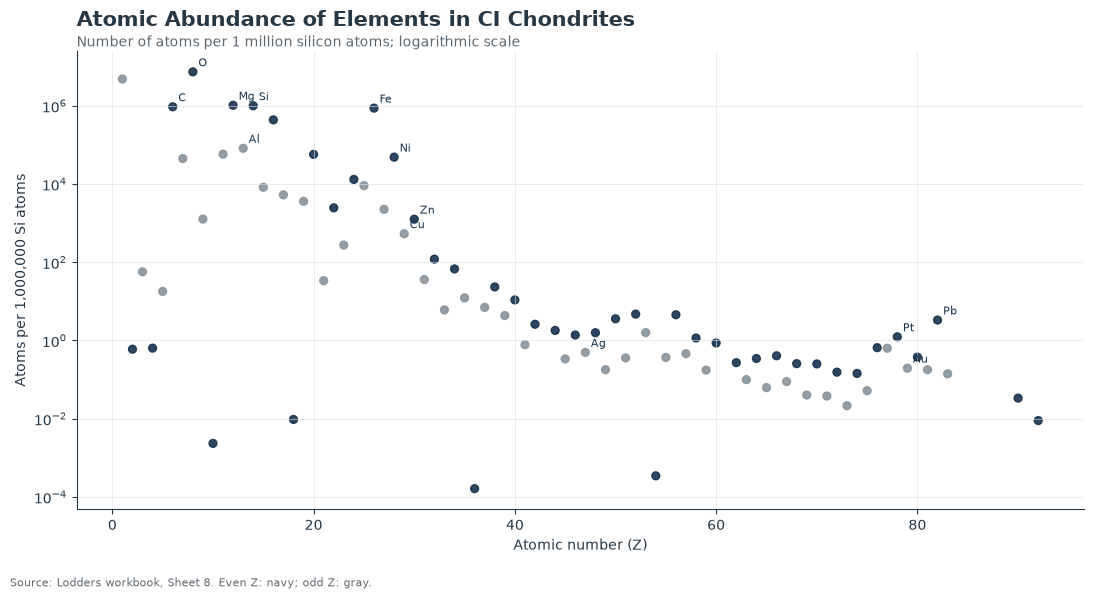

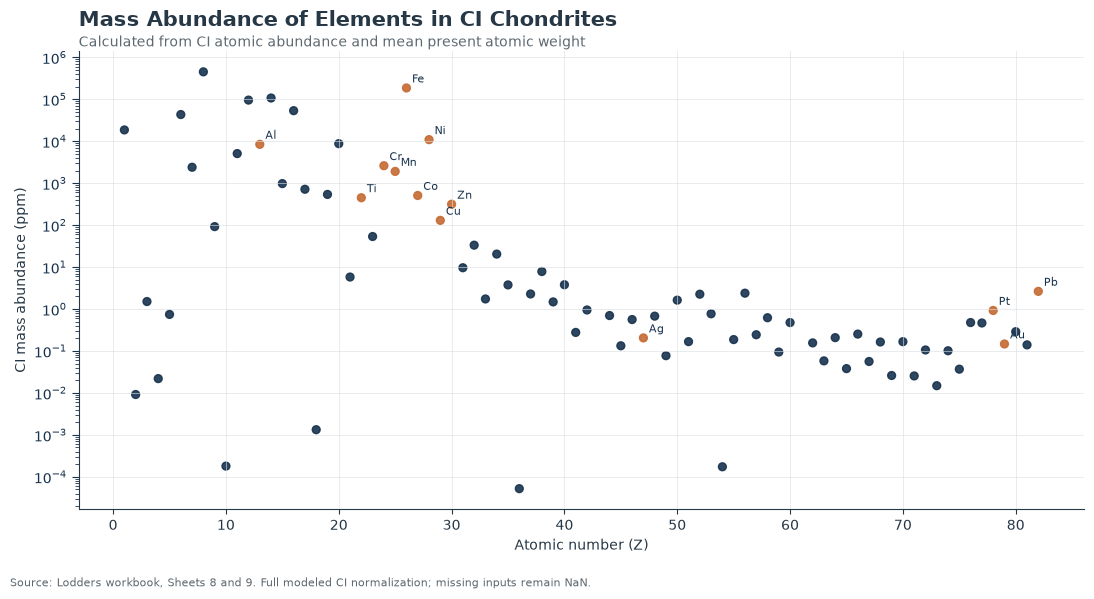

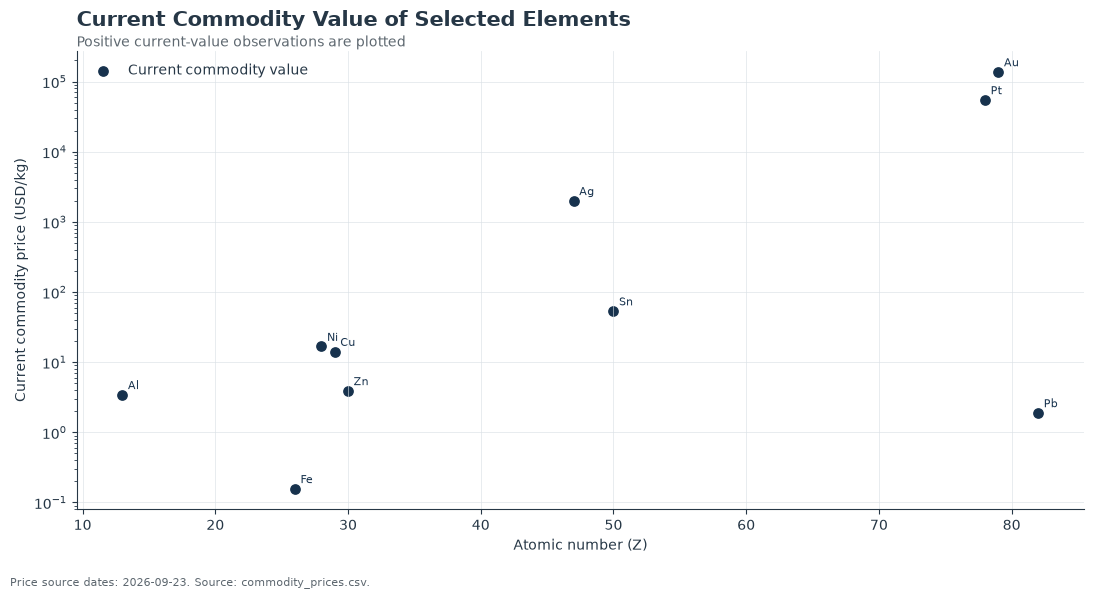

In [51]:
# 11-13. Publication-quality abundance and price charts
NAVY, GRAY, ORANGE, GRID = "#17324D", "#8A939B", "#C56A32", "#D9E0E5"
label_symbols = {"C", "O", "Mg", "Al", "Si", "Fe", "Ni", "Cu", "Zn", "Ag", "Pt", "Au", "Pb"}
industrial_symbols = {"Al", "Fe", "Cu", "Ni", "Zn", "Ag", "Au", "Pt", "Pb", "Ti", "Cr", "Mn", "Co"}

from matplotlib.ticker import LogLocator

def finish_figure(fig, filename, caption):
    fig.text(0.01, 0.01, caption, ha="left", va="bottom", fontsize=8, color="#5E6870")
    fig.tight_layout(rect=(0, 0.045, 1, 1))
    fig.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / filename.replace(".png", ".svg"), bbox_inches="tight")
    plt.show()

def annotate_points(ax, frame, x_col, y_col, symbols):
    for _, row in frame[frame["symbol"].isin(symbols)].iterrows():
        if pd.notna(row[x_col]) and pd.notna(row[y_col]):
            ax.annotate(row["symbol"], (row[x_col], row[y_col]), xytext=(4, 4), textcoords="offset points", fontsize=8, color=NAVY)

def style_axis(ax):
    ax.grid(True, which="major", color=GRID, linewidth=0.6, alpha=0.7)
    ax.grid(False, which="minor")
    ax.spines[["top", "right"]].set_visible(False)

atomic_plot = analysis.dropna(subset=["ci_atomic_abundance"]).query("ci_atomic_abundance > 0")
fig, ax = plt.subplots(figsize=(11, 6))
colors = np.where(atomic_plot["atomic_number"] % 2 == 0, NAVY, GRAY)
ax.scatter(atomic_plot["atomic_number"], atomic_plot["ci_atomic_abundance"], c=colors, s=32, alpha=0.9)
ax.set_yscale("log")
ax.set_xlabel("Atomic number (Z)")
ax.set_ylabel("Atoms per 1,000,000 Si atoms")
ax.set_title("Atomic Abundance of Elements in CI Chondrites", loc="left", pad=18)
ax.text(0, 1.01, "Number of atoms per 1 million silicon atoms; logarithmic scale", transform=ax.transAxes, fontsize=10, color="#5E6870")
annotate_points(ax, atomic_plot, "atomic_number", "ci_atomic_abundance", label_symbols)
style_axis(ax)
finish_figure(fig, "01_ci_atomic_abundance.png", "Source: Lodders workbook, Sheet 8. Even Z: navy; odd Z: gray.")

mass_plot = analysis.dropna(subset=["ci_mass_ppm"]).query("ci_mass_ppm > 0")
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(mass_plot["atomic_number"], mass_plot["ci_mass_ppm"], c=np.where(mass_plot["symbol"].isin(industrial_symbols), ORANGE, NAVY), s=32, alpha=0.9)
ax.set_yscale("log")
ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=20))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
ax.tick_params(axis="y", which="major", direction="out", length=5, width=0.8, colors=NAVY)
ax.tick_params(axis="y", which="minor", direction="out", length=3, width=0.6, colors=NAVY)
ax.set_xlabel("Atomic number (Z)")
ax.set_ylabel("CI mass abundance (ppm)")
ax.set_title("Mass Abundance of Elements in CI Chondrites", loc="left", pad=18)
ax.text(0, 1.01, "Calculated from CI atomic abundance and mean present atomic weight", transform=ax.transAxes, fontsize=10, color="#5E6870")
annotate_points(ax, mass_plot, "atomic_number", "ci_mass_ppm", industrial_symbols)
style_axis(ax)
finish_figure(fig, "02_ci_mass_abundance.png", "Source: Lodders workbook, Sheets 8 and 9. Full modeled CI normalization; missing inputs remain NaN.")

price_plot = analysis[analysis["log_price"].notna() & analysis["price_quality"].isin(["benchmark", "industrial_quote", "proxy"])].copy()
price_plot["display_quality"] = np.where(price_plot["symbol"] == "Fe", "benchmark", price_plot["price_quality"])
current_element_prices = price_plot

if price_plot.empty:
    print("Commodity price chart skipped: no positive benchmark or industrial_quote observations are present in commodity_prices.csv.")
else:
    fig, ax = plt.subplots(figsize=(11, 6))
    for quality, color, marker, label in [
        ("benchmark", NAVY, "o", "Current commodity value"),
        ("industrial_quote", ORANGE, "s", "Industrial quotation"),
        ("proxy", GRAY, "D", "Material proxy"),
    ]:
        subset = price_plot[price_plot["display_quality"] == quality]
        if not subset.empty:
            ax.scatter(subset["atomic_number"], subset["price_usd_per_kg"], c=color, marker=marker, s=45, label=label)

    ax.set_yscale("log")
    ax.set_xlabel("Atomic number (Z)")
    ax.set_ylabel("Current commodity price (USD/kg)")
    ax.set_title("Current Commodity Value of Selected Elements", loc="left", pad=18)
    ax.text(0, 1.01, "Positive current-value observations are plotted", transform=ax.transAxes, fontsize=10, color="#5E6870")
    annotate_points(ax, price_plot, "atomic_number", "price_usd_per_kg", set(price_plot["symbol"]))
    style_axis(ax)
    ax.legend(frameon=False)

    price_dates = ", ".join(sorted(price_plot["price_date"].dropna().astype(str).unique()))
    finish_figure(
        fig,
        "03_current_element_prices.png",
        f"Price source dates: {price_dates}. Source: commodity_prices.csv.",
    )

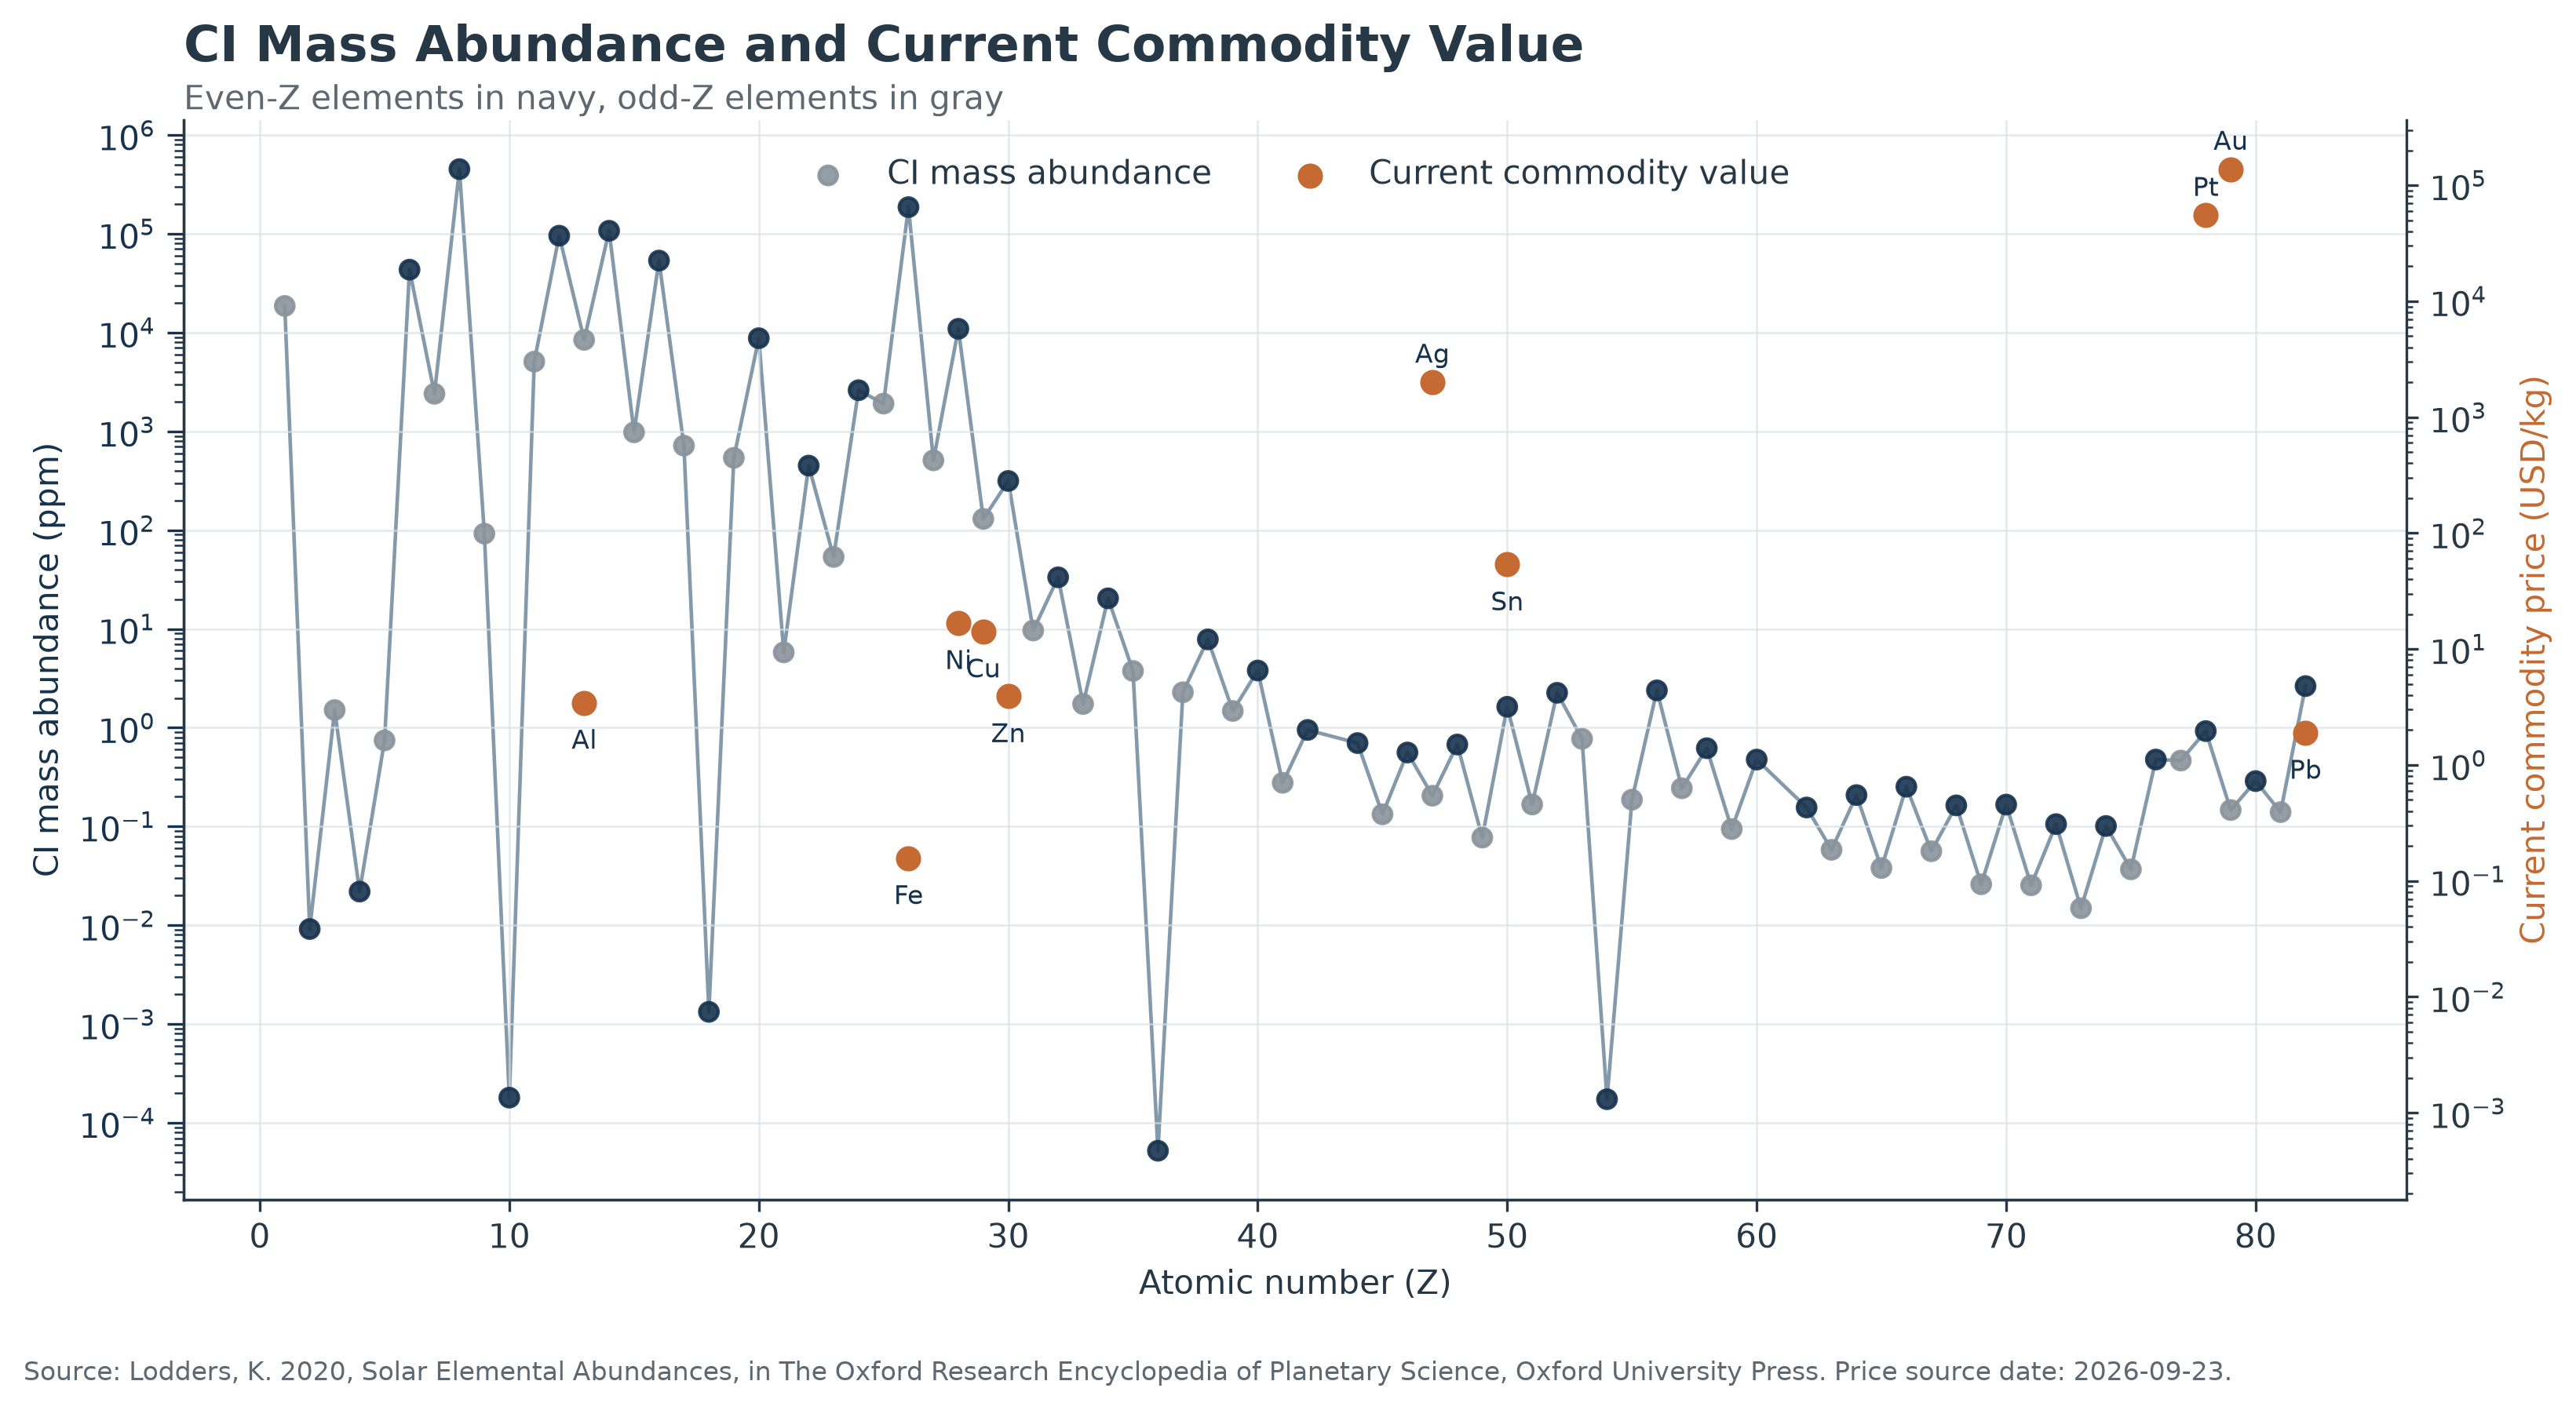

In [50]:
# 13b. Combined CI mass abundance and commodity-value chart
# Both axes are logarithmic so relative differences remain visible across wide ranges.
from matplotlib.ticker import LogLocator

combined_mass_plot = mass_plot.dropna(subset=["atomic_number", "ci_mass_ppm"]).query("ci_mass_ppm > 0")
combined_mass_sorted = combined_mass_plot.sort_values("atomic_number")
combined_price_plot = price_plot.dropna(subset=["atomic_number", "price_usd_per_kg"]).query("price_usd_per_kg > 0")
tin_scale_row = combined_price_plot.loc[combined_price_plot["symbol"] == "Sn"].iloc[0]
expected_scale_values = (
    tin_scale_row["price_usd_per_kg"]
    * tin_scale_row["ci_mass_ppm"]
    / combined_price_plot["ci_mass_ppm"]
).to_numpy()
commodity_scale_values = np.concatenate(
    [combined_price_plot["price_usd_per_kg"].to_numpy(), expected_scale_values]
)

fig, mass_ax = plt.subplots(figsize=(11, 6), dpi=300)
price_ax = mass_ax.twinx()

mass_ax.plot(
    combined_mass_sorted["atomic_number"],
    combined_mass_sorted["ci_mass_ppm"],
    color=SAWTOOTH_LINE,
    linewidth=1.1,
    alpha=0.85,
    zorder=1,
)
mass_ax.scatter(
    combined_mass_plot["atomic_number"],
    combined_mass_plot["ci_mass_ppm"],
    c=np.where(combined_mass_plot["atomic_number"] % 2 == 0, NAVY, GRAY),
    s=32,
    alpha=0.9,
    zorder=2,
    label="CI mass abundance",
)

for quality, marker, label in [
    ("benchmark", "o", "Current commodity value"),
    ("industrial_quote", "s", "Industrial quotation"),
    ("proxy", "D", "Material proxy"),
]:
    subset = combined_price_plot[combined_price_plot["display_quality"] == quality]
    if not subset.empty:
        price_ax.scatter(
            subset["atomic_number"],
            subset["price_usd_per_kg"],
            c=ORANGE,
            marker=marker,
            s=45,
            label=label,
        )

mass_ax.set_yscale("log")
price_ax.set_yscale("log")
price_log_min = np.log10(commodity_scale_values.min())
price_log_max = np.log10(commodity_scale_values.max())
price_log_margin = 0.05 * (price_log_max - price_log_min)
price_ax.set_ylim(
    10 ** (price_log_min - price_log_margin),
    10 ** (price_log_max + price_log_margin),
)
mass_ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=20))
mass_ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
mass_ax.tick_params(axis="y", which="major", direction="out", length=5, width=0.8, colors=NAVY)
mass_ax.tick_params(axis="y", which="minor", direction="out", length=3, width=0.6, colors=NAVY)
mass_ax.set_xlabel("Atomic number (Z)")
mass_ax.set_ylabel("CI mass abundance (ppm)", color=NAVY)
price_ax.set_ylabel("Current commodity price (USD/kg)", color=ORANGE)
mass_ax.set_title("CI Mass Abundance and Current Commodity Value", loc="left", pad=18)
mass_ax.text(0, 1.01, "Even-Z elements in navy, odd-Z elements in gray", transform=mass_ax.transAxes, fontsize=10, color="#5E6870")

labels_above = {"Ag", "Pt", "Au"}
labels_below = {"Al", "Fe", "Ni", "Cu", "Zn", "Sn", "Pb"}
for _, row in combined_price_plot.iterrows():
    if row["symbol"] in labels_above or row["symbol"] in labels_below:
        is_above = row["symbol"] in labels_above
        price_ax.annotate(
            row["symbol"],
            (row["atomic_number"], row["price_usd_per_kg"]),
            xytext=(0, 4 if is_above else -8),
            textcoords="offset points",
            ha="center",
            va="bottom" if is_above else "top",
            fontsize=8,
            color=NAVY,
        )

style_axis(mass_ax)
price_ax.spines["top"].set_visible(False)
handles_left, labels_left = mass_ax.get_legend_handles_labels()
handles_right, labels_right = price_ax.get_legend_handles_labels()
fig.legend(
    handles_left + handles_right,
    labels_left + labels_right,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.90),
    ncol=3,
)
combined_dates = ", ".join(sorted(combined_price_plot["price_date"].dropna().astype(str).unique())) or "Dates not supplied"
finish_figure(fig, "06_mass_abundance_and_commodity_value.png", f"Source: Lodders, K. 2020, Solar Elemental Abundances, in The Oxford Research Encyclopedia of Planetary Science, Oxford University Press. Price source date: {combined_dates}.")

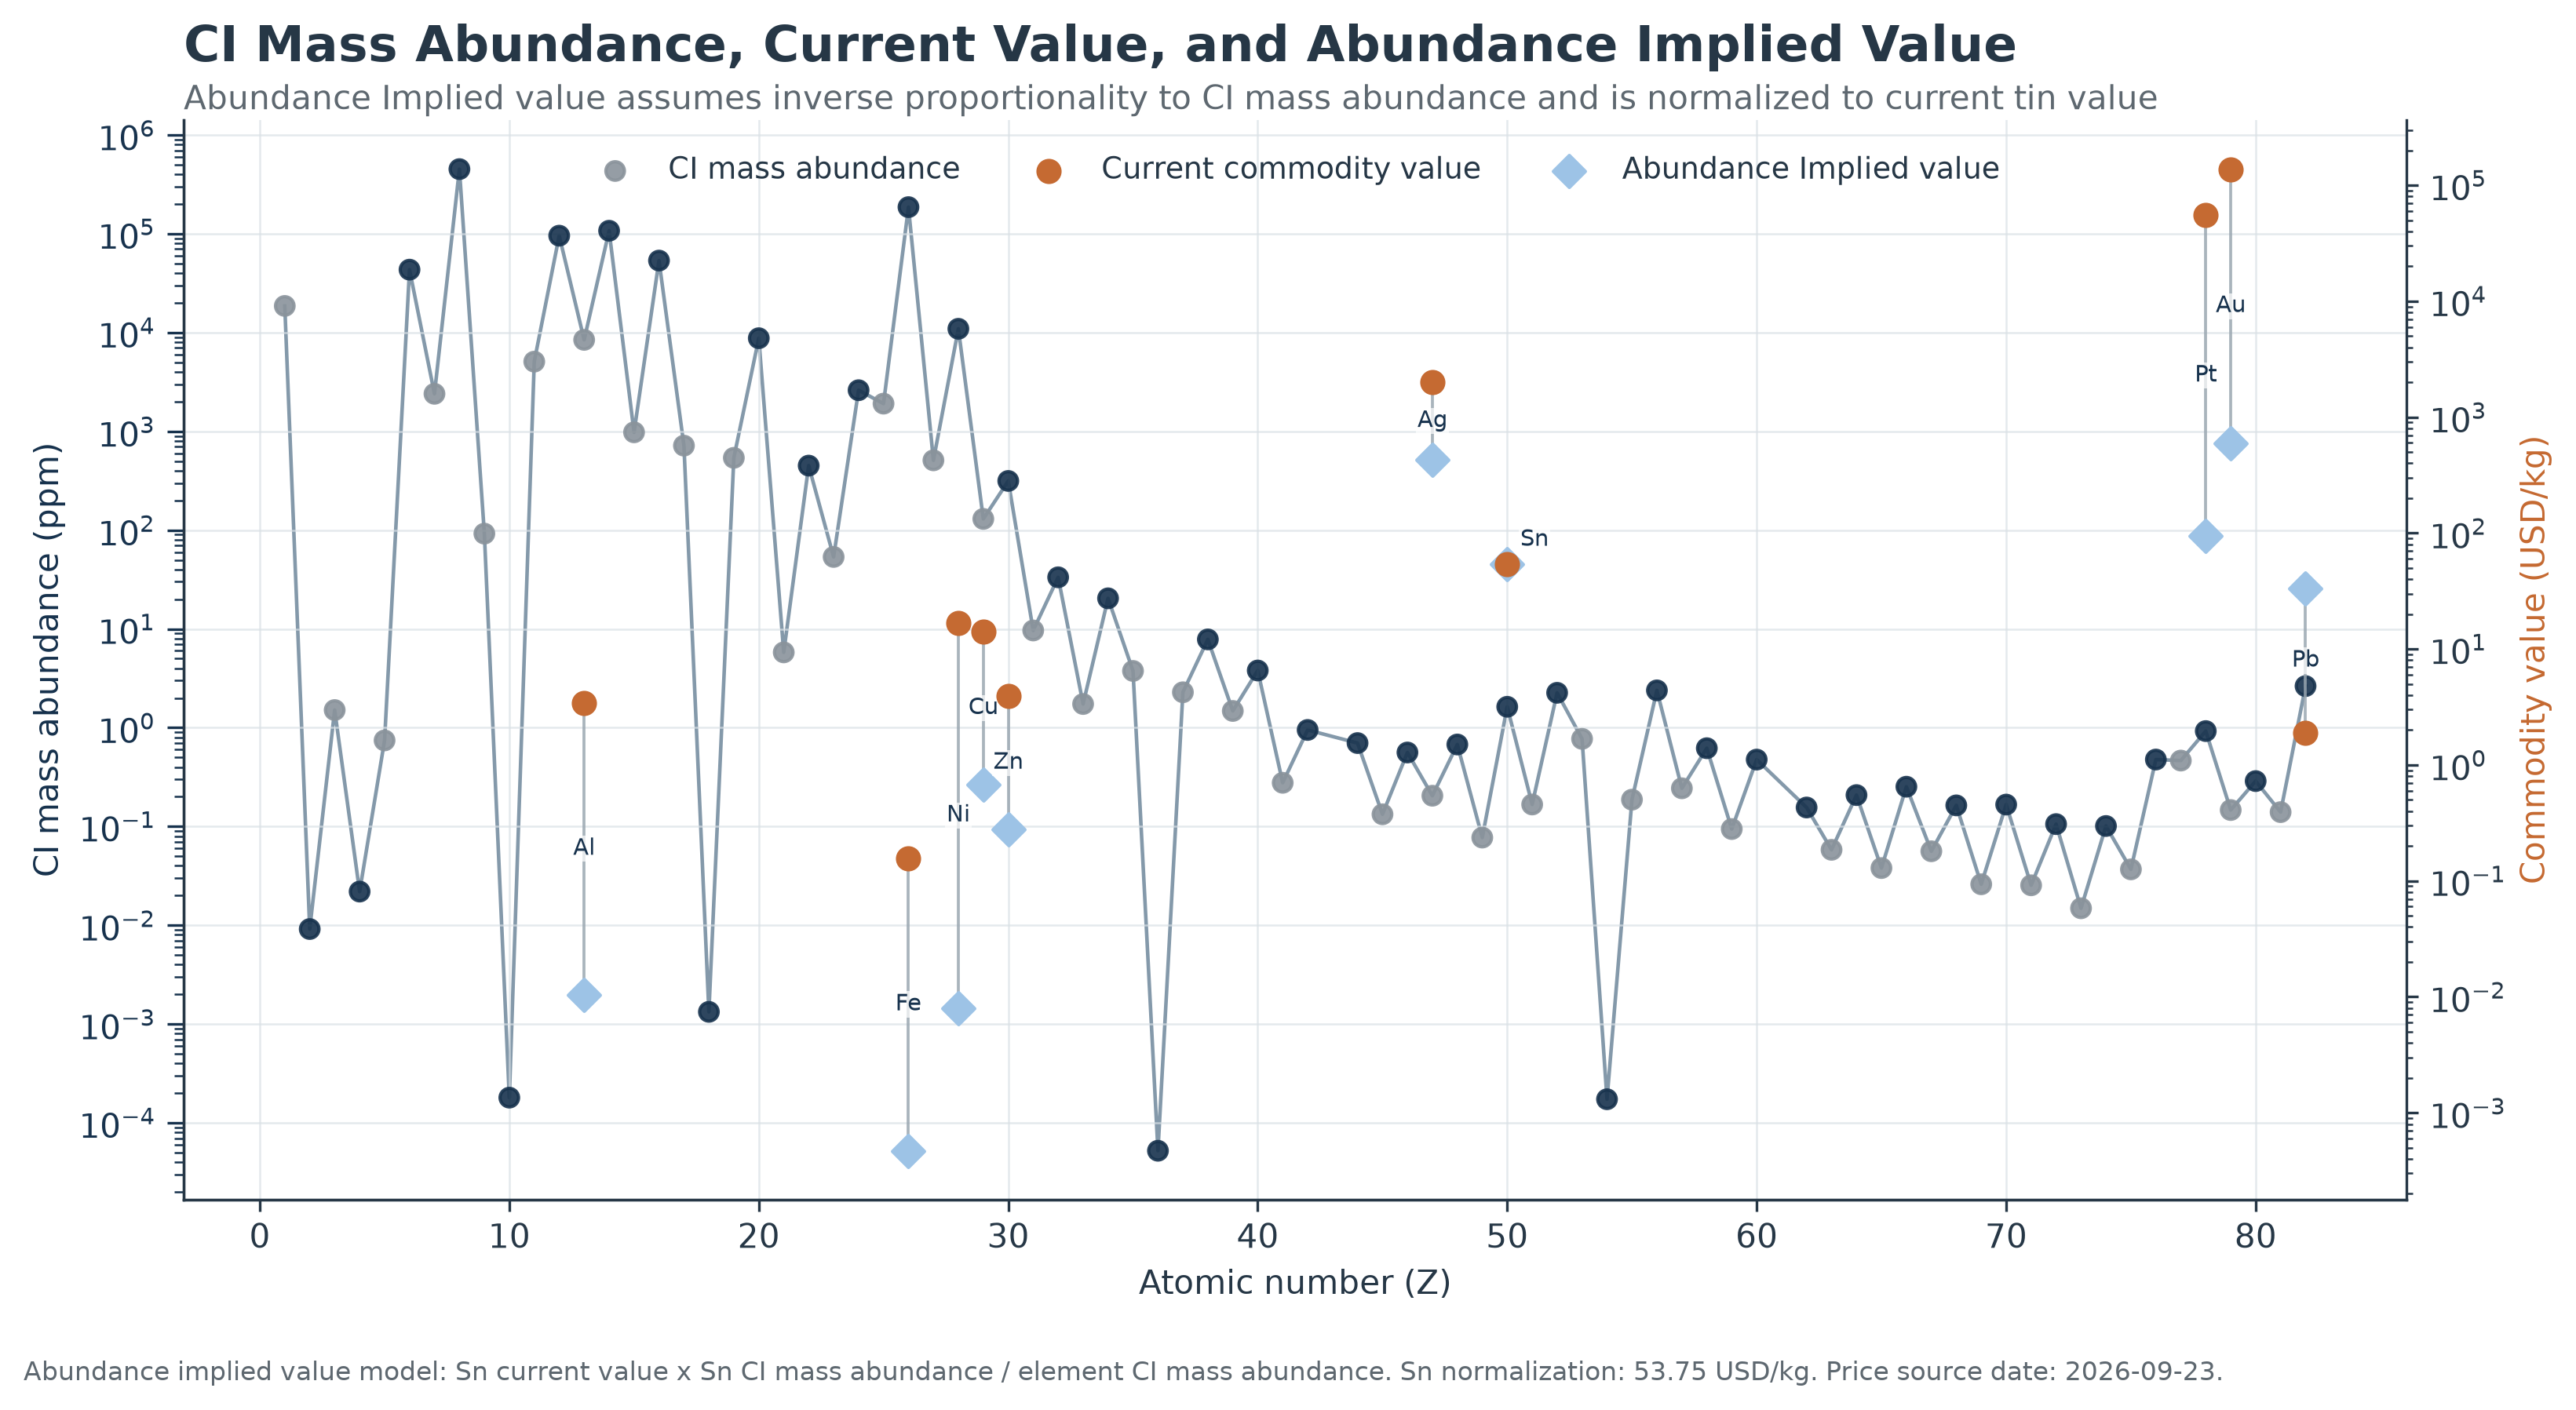

In [55]:
# 13c. Abundance-implied expected commodity value, normalized to tin
# Method: expected value is inversely proportional to CI mass abundance and equals
# tin's current price at tin's CI mass abundance.
from matplotlib.ticker import LogLocator

EXPECTED_VALUE = "#9DC3E6"
VALUE_CONNECTOR = "#9AA7B1"

expected_value_plot = combined_price_plot.copy()
expected_value_plot["display_quality"] = np.where(expected_value_plot["symbol"] == "Fe", "benchmark", expected_value_plot["price_quality"])
tin_row = expected_value_plot.loc[expected_value_plot["symbol"] == "Sn"]
if tin_row.empty:
    raise ValueError("Tin (Sn) is required as the normalization anchor for expected value.")
tin_price_usd_per_kg = tin_row["price_usd_per_kg"].iloc[0]
tin_mass_ppm = tin_row["ci_mass_ppm"].iloc[0]
expected_value_plot["expected_price_usd_per_kg"] = (
    tin_price_usd_per_kg * tin_mass_ppm / expected_value_plot["ci_mass_ppm"]
)

fig, mass_ax = plt.subplots(figsize=(11, 6), dpi=300)
price_ax = mass_ax.twinx()

mass_ax.plot(
    combined_mass_sorted["atomic_number"],
    combined_mass_sorted["ci_mass_ppm"],
    color=SAWTOOTH_LINE,
    linewidth=1.1,
    alpha=0.85,
    zorder=1,
)
mass_ax.scatter(
    combined_mass_plot["atomic_number"],
    combined_mass_plot["ci_mass_ppm"],
    c=np.where(combined_mass_plot["atomic_number"] % 2 == 0, NAVY, GRAY),
    s=32,
    alpha=0.9,
    zorder=2,
    label="CI mass abundance",
)

for quality, marker, label in [
    ("benchmark", "o", "Current commodity value"),
    ("industrial_quote", "s", "Current industrial quotation"),
    ("proxy", "D", "Current material proxy"),
]:
    subset = expected_value_plot[expected_value_plot["display_quality"] == quality]
    if not subset.empty:
        price_ax.scatter(
            subset["atomic_number"],
            subset["price_usd_per_kg"],
            c=ORANGE,
            marker=marker,
            s=45,
            label=label,
            zorder=6,
        )

for row in expected_value_plot.itertuples():
    current_value = row.price_usd_per_kg
    expected_value = row.expected_price_usd_per_kg
    midpoint = np.sqrt(current_value * expected_value)
    is_tin = row.symbol == "Sn"
    price_ax.vlines(
        row.atomic_number,
        min(current_value, expected_value),
        max(current_value, expected_value),
        color=VALUE_CONNECTOR,
        linewidth=0.9,
        alpha=0.85,
        zorder=2,
    )
    price_ax.annotate(
        row.symbol,
        (row.atomic_number, midpoint),
        xytext=(4, 4) if is_tin else (0, 0),
        textcoords="offset points",
        ha="left" if is_tin else "center",
        va="bottom" if is_tin else "center",
        fontsize=7,
        color=NAVY,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.7, "pad": 0.5},
        zorder=5,
    )

price_ax.scatter(
    expected_value_plot["atomic_number"],
    expected_value_plot["expected_price_usd_per_kg"],
    facecolors=EXPECTED_VALUE,
    edgecolors=EXPECTED_VALUE,
    marker="D",
    s=48,
    linewidth=1.0,
    label="Abundance Implied value",
    zorder=4,
)

mass_ax.set_yscale("log")
price_ax.set_yscale("log")
mass_ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=20))
mass_ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
mass_ax.tick_params(axis="y", which="major", direction="out", length=5, width=0.8, colors=NAVY)
mass_ax.tick_params(axis="y", which="minor", direction="out", length=3, width=0.6, colors=NAVY)
mass_ax.set_xlabel("Atomic number (Z)")
mass_ax.set_ylabel("CI mass abundance (ppm)", color=NAVY)
price_ax.set_ylabel("Commodity value (USD/kg)", color=ORANGE)
mass_ax.set_title("CI Mass Abundance, Current Value, and Abundance Implied Value", loc="left", pad=18)
mass_ax.text(
    0,
    1.01,
    "Abundance Implied value assumes inverse proportionality to CI mass abundance and is normalized to current tin value",
    transform=mass_ax.transAxes,
    fontsize=10,
    color="#5E6870",
)

style_axis(mass_ax)
price_ax.spines["top"].set_visible(False)
handles_left, labels_left = mass_ax.get_legend_handles_labels()
handles_right, labels_right = price_ax.get_legend_handles_labels()
fig.legend(
    handles_left + handles_right,
    labels_left + labels_right,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.90),
    ncol=3,
    fontsize=9,
)
combined_dates = ", ".join(sorted(expected_value_plot["price_date"].dropna().astype(str).unique())) or "Dates not supplied"
finish_figure(
    fig,
    "07_mass_abundance_current_and_expected_value.png",
    f"Abundance implied value model: Sn current value x Sn CI mass abundance / element CI mass abundance. Sn normalization: {tin_price_usd_per_kg:,.2f} USD/kg. Price source date: {combined_dates}.",
)

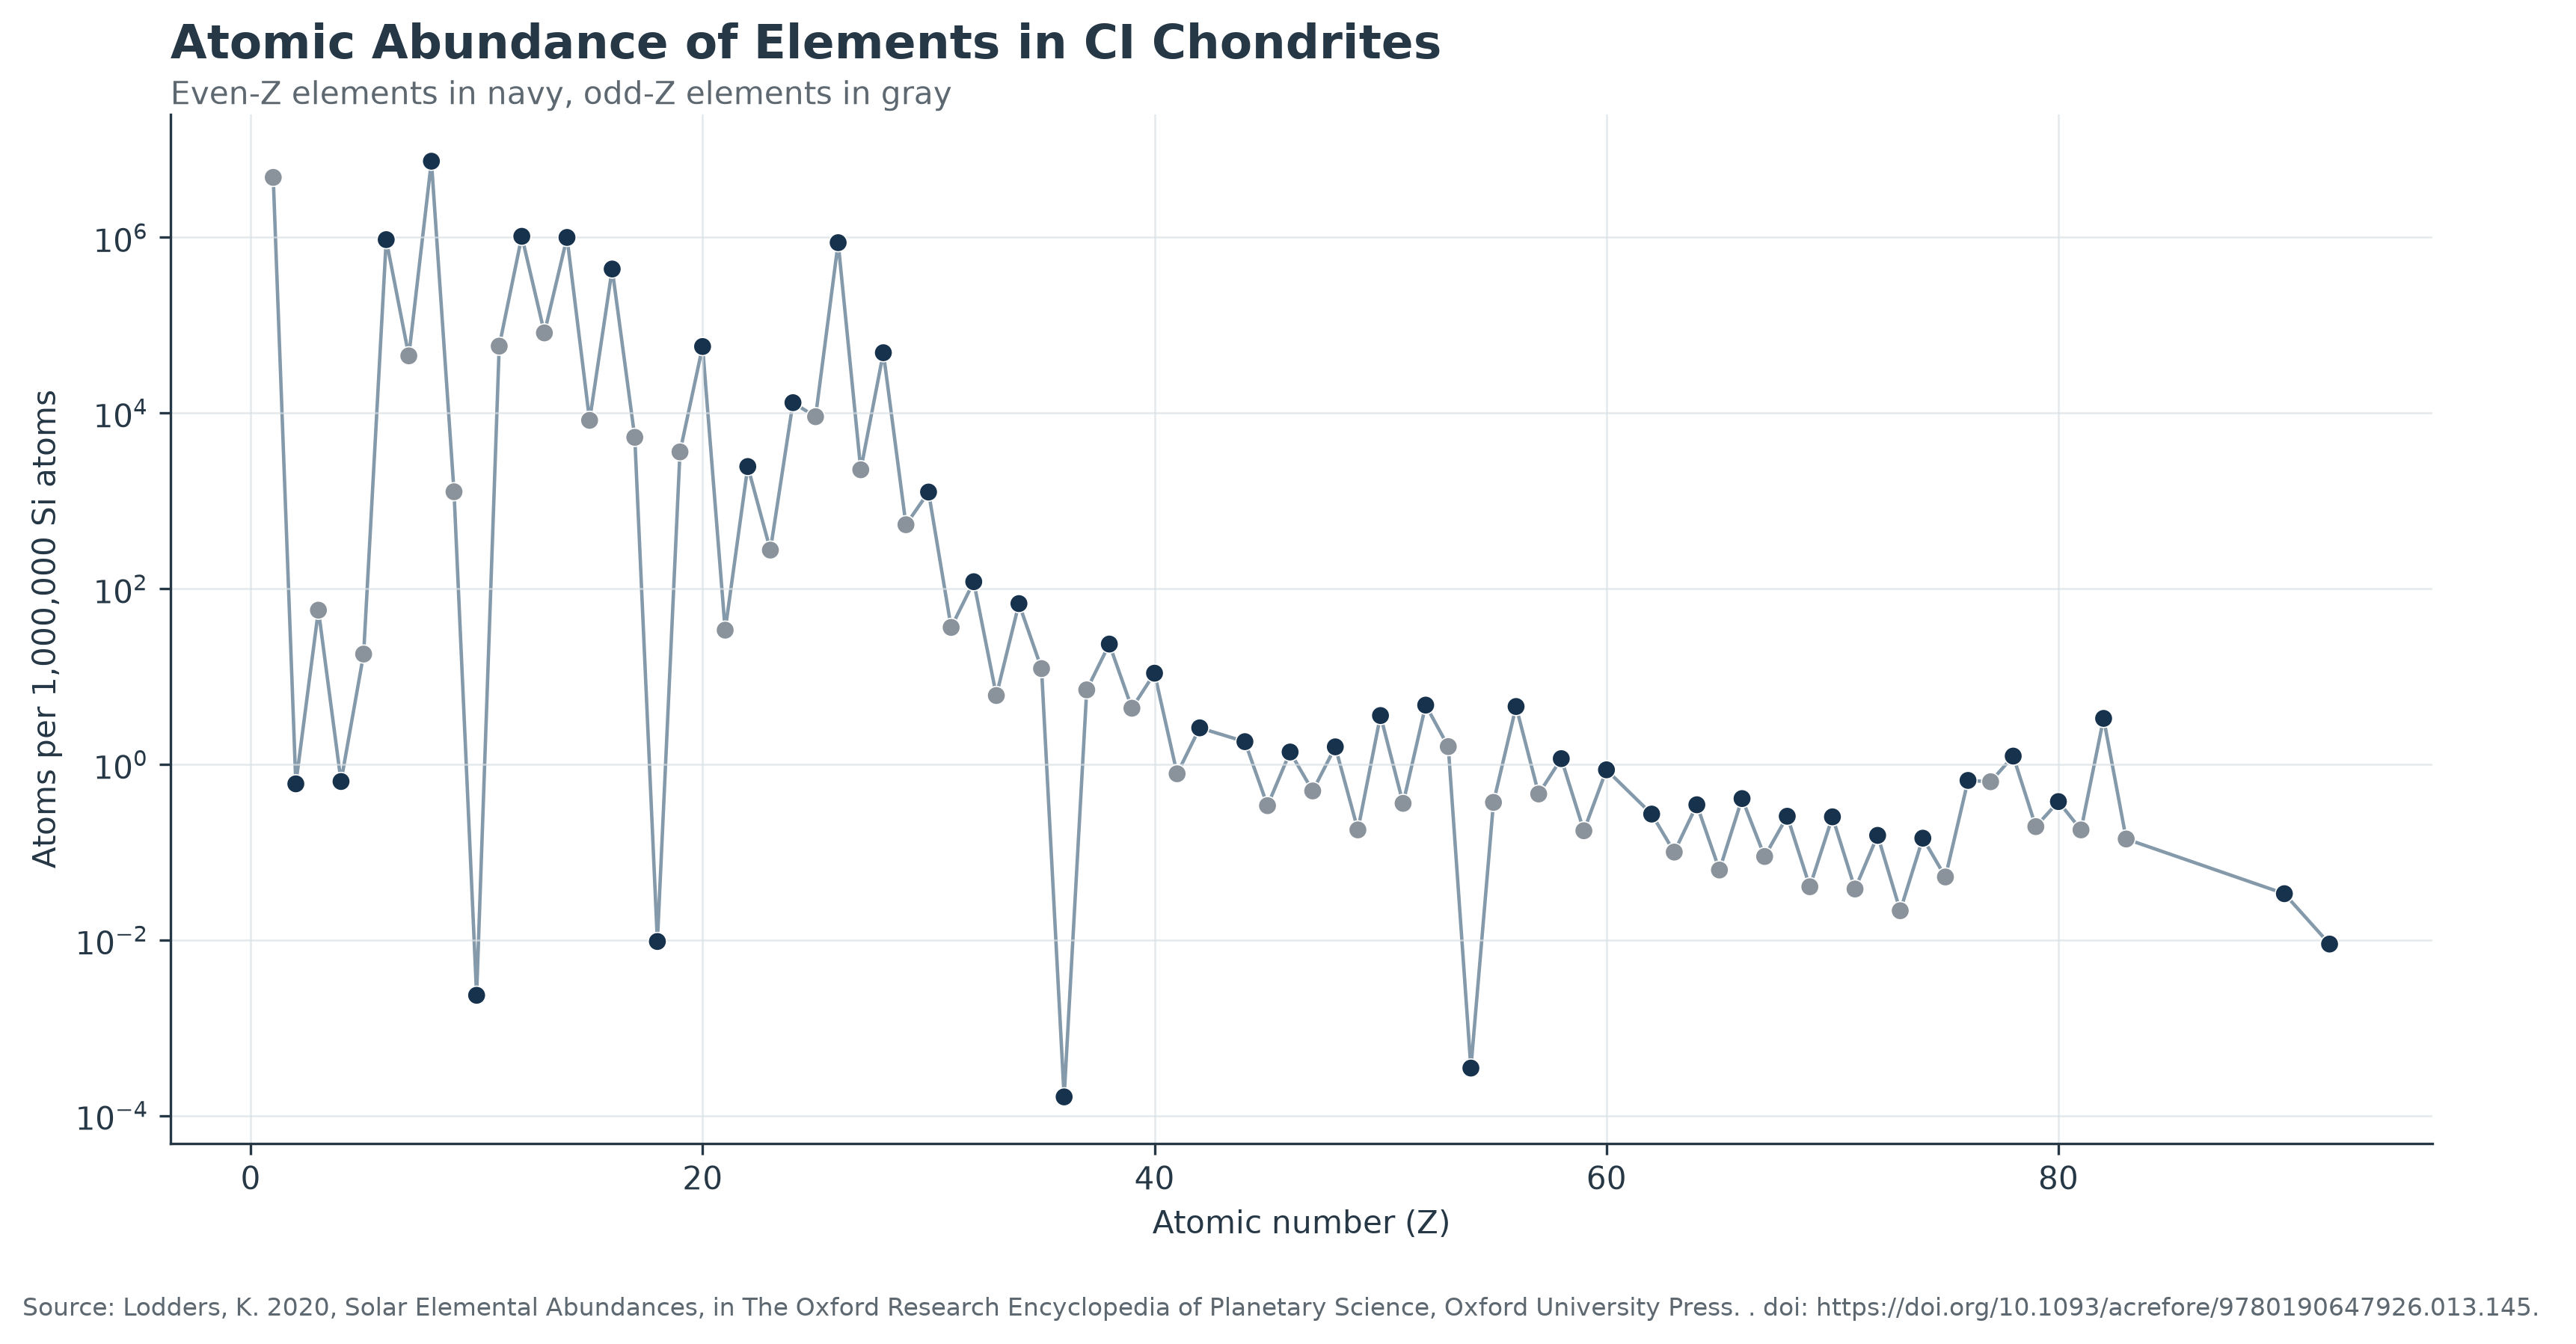

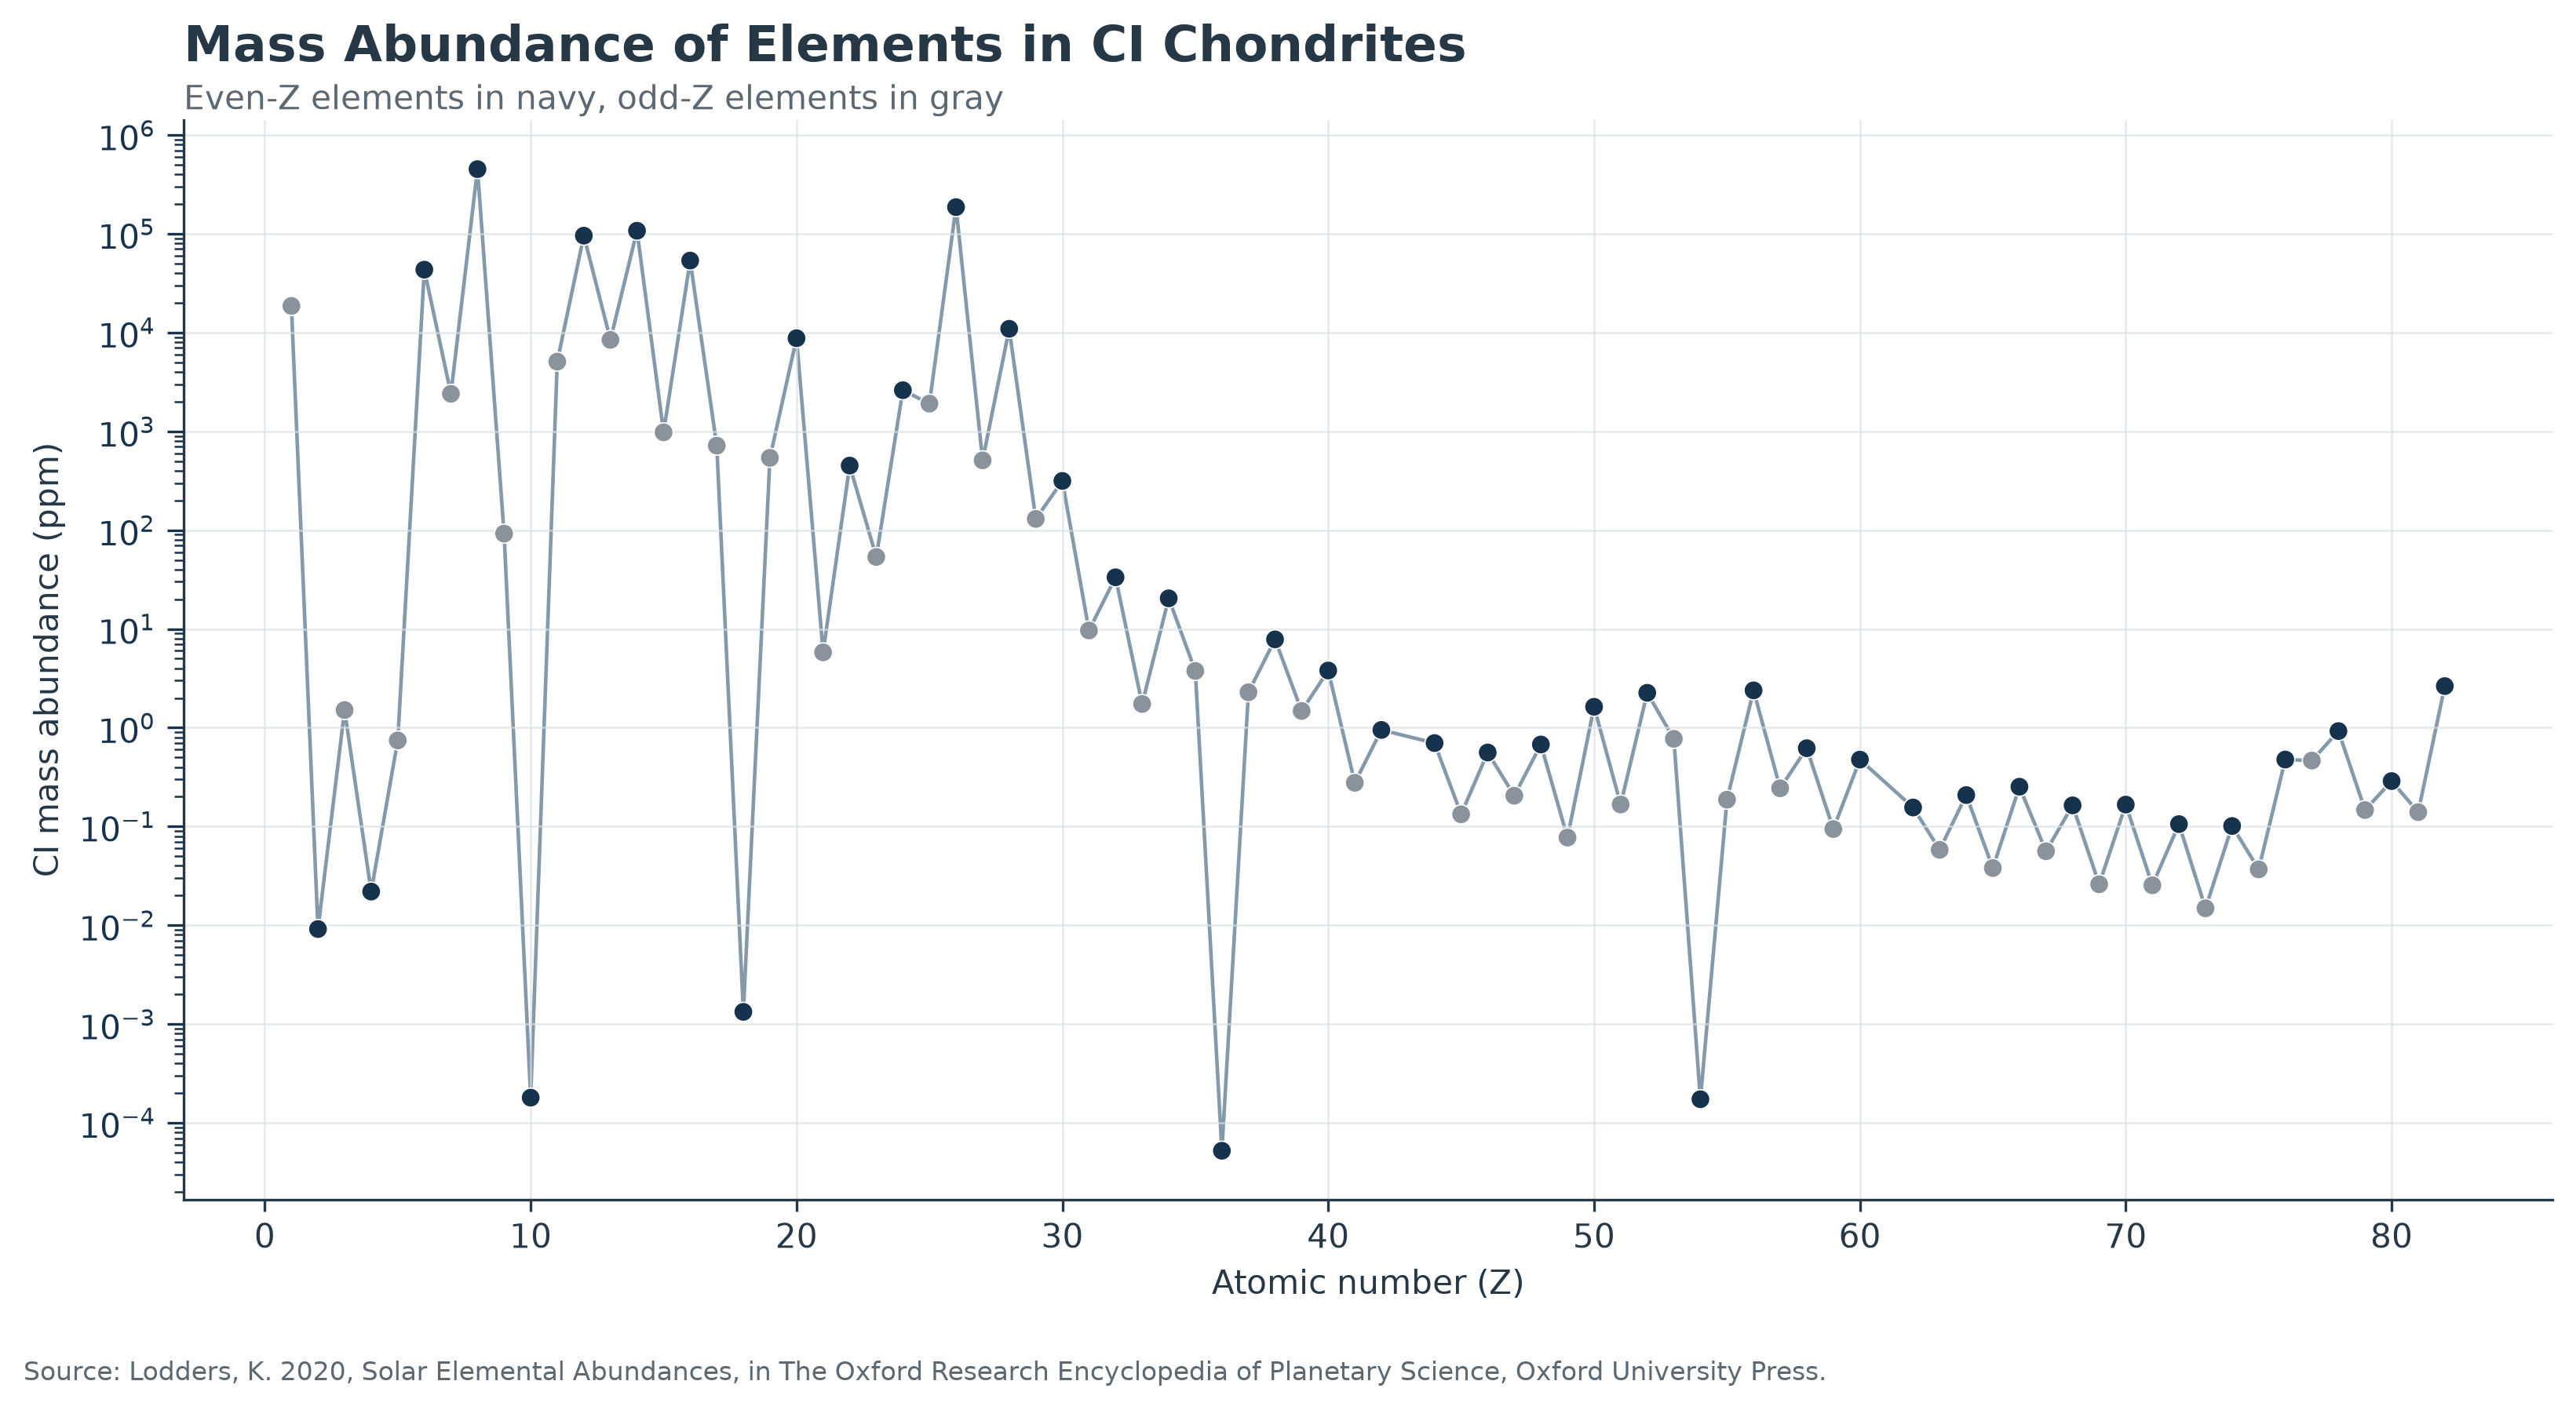

In [52]:
# 11b. Alternate connected-line charts for the Oddo-Harkins sawtooth pattern
# The line connects adjacent atomic numbers in Z order; it is a visual guide, not an interpolation of missing observations.
from matplotlib.ticker import LogLocator

SAWTOOTH_LINE = "#6E879B"

def connected_abundance_chart(frame, y_column, y_label, title, subtitle, filename, caption, label_set):
    plot_data = frame.dropna(subset=["atomic_number", y_column]).query(f"{y_column} > 0").sort_values("atomic_number")
    fig, ax = plt.subplots(figsize=(11, 6), dpi=300)
    ax.plot(plot_data["atomic_number"], plot_data[y_column], color=SAWTOOTH_LINE, linewidth=1.1, alpha=0.85, zorder=1)
    point_colors = np.where(plot_data["atomic_number"] % 2 == 0, NAVY, GRAY)
    ax.scatter(plot_data["atomic_number"], plot_data[y_column], c=point_colors, s=34, edgecolor="white", linewidth=0.4, zorder=2)
    ax.set_yscale("log")
    if y_column == "ci_mass_ppm":
        ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=20))
        ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
        ax.tick_params(axis="y", which="major", direction="out", length=5, width=0.8, colors=NAVY)
        ax.tick_params(axis="y", which="minor", direction="out", length=3, width=0.6, colors=NAVY)
    ax.set_xlabel("Atomic number (Z)")
    ax.set_ylabel(y_label)
    ax.set_title(title, loc="left", pad=18)
    ax.text(0, 1.01, subtitle, transform=ax.transAxes, fontsize=10, color="#5E6870")
    #annotate_points(ax, plot_data, "atomic_number", y_column, label_set)
    style_axis(ax)
    finish_figure(fig, filename, caption)

connected_abundance_chart(
    atomic_plot,
    "ci_atomic_abundance",
    "Atoms per 1,000,000 Si atoms",
    "Atomic Abundance of Elements in CI Chondrites",
    "Even-Z elements in navy, odd-Z elements in gray",
    "01b_ci_atomic_abundance_connected.png",
    "Source: Lodders, K. 2020, Solar Elemental Abundances, in The Oxford Research Encyclopedia of Planetary Science, Oxford University Press. . doi: https://doi.org/10.1093/acrefore/9780190647926.013.145.  ",
    label_symbols
)

connected_abundance_chart(
    mass_plot,
    "ci_mass_ppm",
    "CI mass abundance (ppm)",
    "Mass Abundance of Elements in CI Chondrites",
    "Even-Z elements in navy, odd-Z elements in gray", 
    "02b_ci_mass_abundance_connected.png",
    "Source: Lodders, K. 2020, Solar Elemental Abundances, in The Oxford Research Encyclopedia of Planetary Science, Oxford University Press.",
    industrial_symbols,
)

n=9; Pearson r=-0.693, p=0.0385; Spearman rho=-0.717, p=0.0298


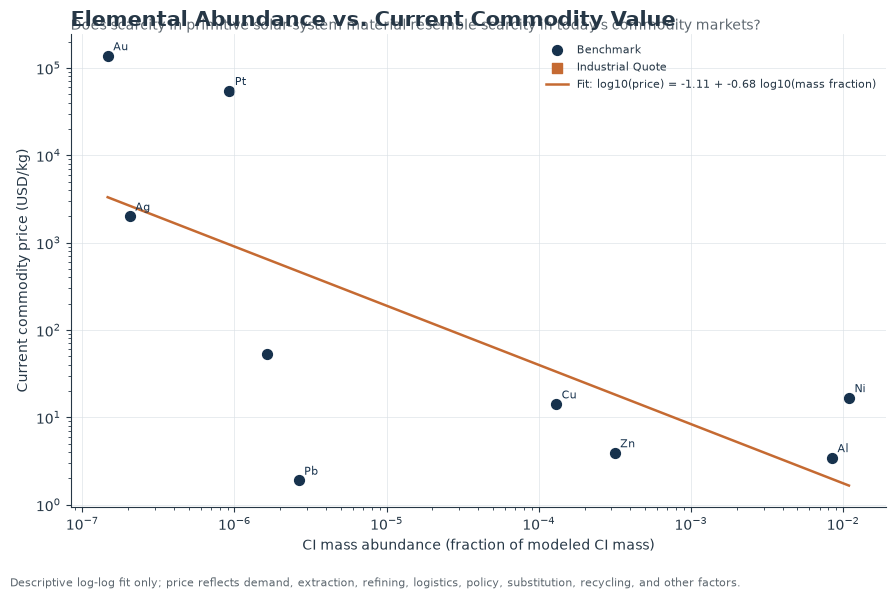

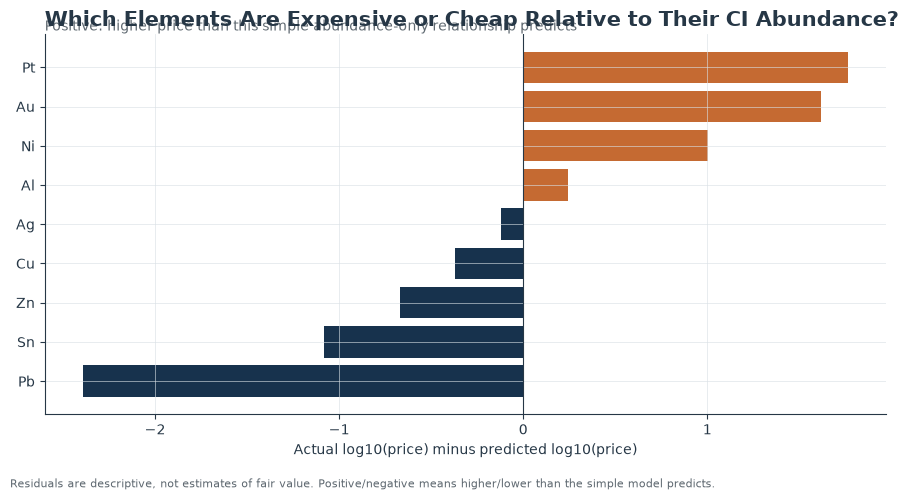

,atomic_number,symbol,element_name,ci_atomic_abundance,ci_atomic_sigma,mean_atomic_weight,ci_mass_fraction,ci_mass_percent,ci_mass_ppm,price_usd_per_kg,price_date,price_source,price_quality,log_mass_abundance,log_price,predicted_log_price,regression_residual
12,13,Al,Aluminium,81820.000,6110.000,26.981539,8.438204e-03,0.843820,8438.204405,3.446404,2026-09-23,Yahoo Finance,benchmark,-2.073750,0.537366,0.294210,0.243156
25,26,Fe,Iron,872000.000,38000.000,55.845145,1.861340e-01,18.613402,186134.021090,0.157363,2026-09-23,Investing.com daily snapshot,proxy,-0.730174,-0.803097,NaN,NaN
27,28,Ni,Nickel,48670.000,2940.000,58.693352,1.091878e-02,1.091878,10918.779957,16.772457,2026-09-23,Investing.com daily snapshot,benchmark,-1.961826,1.224597,0.218351,1.006246
28,29,Cu,Copper,535.000,50.000,63.545560,1.299460e-04,0.012995,129.945980,14.188392,2026-09-23,Yahoo Finance,benchmark,-3.886237,1.151933,1.522665,-0.370732
29,30,Zn,Zinc,1260.000,180.000,65.377765,3.148651e-04,0.031487,314.865062,3.921766,2026-09-23,Yahoo Finance,benchmark,-3.501876,0.593482,1.262155,-0.668673
46,47,Ag,Silver,0.497,0.022,107.868147,2.049149e-07,0.000020,0.204915,2008.650034,2026-09-23,Yahoo Finance,benchmark,-6.688427,3.302904,3.421913,-0.119008
49,50,Sn,Tin,3.590,0.220,118.710350,1.628947e-06,0.000163,1.628947,53.753079,2026-09-23,Investing.com daily snapshot,benchmark,-5.788093,1.730403,2.811691,-1.081288
77,78,Pt,Platinum,1.240,0.100,195.083945,9.246281e-07,0.000092,0.924628,55101.631032,2026-09-23,Yahoo Finance,benchmark,-6.034033,4.741164,2.978382,1.762782
78,79,Au,Gold,0.195,0.016,196.966569,1.468084e-07,0.000015,0.146808,137744.036810,2026-09-23,Yahoo Finance,benchmark,-6.833249,5.139073,3.520069,1.619003
81,82,Pb,Lead,3.330,0.200,207.318870,2.638803e-06,0.000264,2.638803,1.897629,2026-09-23,Investing.com daily snapshot,benchmark,-5.578593,0.278211,2.669698,-2.391486


In [9]:
# 14-16. Abundance-price regression, residuals, and summary export
from scipy.stats import pearsonr, spearmanr

regression_data = analysis[analysis["log_price"].notna() & analysis["price_quality"].isin(["benchmark", "industrial_quote"])].copy()
regression_data = regression_data.replace([np.inf, -np.inf], np.nan).dropna(subset=["log_mass_abundance", "log_price"])
if len(regression_data) >= 3:
    x = regression_data["log_mass_abundance"].to_numpy()
    y = regression_data["log_price"].to_numpy()
    beta, alpha = np.polyfit(x, y, 1)
    regression_data["predicted_log_price"] = alpha + beta * regression_data["log_mass_abundance"]
    regression_data["regression_residual"] = regression_data["log_price"] - regression_data["predicted_log_price"]
    pearson = pearsonr(x, y)
    spearman = spearmanr(x, y)
    print(f"n={len(regression_data)}; Pearson r={pearson.statistic:.3f}, p={pearson.pvalue:.3g}; Spearman rho={spearman.statistic:.3f}, p={spearman.pvalue:.3g}")
    fig, ax = plt.subplots(figsize=(9, 6))
    for quality, color, marker in [("benchmark", NAVY, "o"), ("industrial_quote", ORANGE, "s")]:
        subset = regression_data[regression_data["price_quality"] == quality]
        ax.scatter(subset["ci_mass_fraction"], subset["price_usd_per_kg"], c=color, marker=marker, s=50, label=quality.replace("_", " ").title())
    line_x = np.logspace(regression_data["log_mass_abundance"].min(), regression_data["log_mass_abundance"].max(), 100)
    ax.plot(line_x, 10 ** (alpha + beta * np.log10(line_x)), color=ORANGE, linewidth=1.8, label=f"Fit: log10(price) = {alpha:.2f} + {beta:.2f} log10(mass fraction)")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("CI mass abundance (fraction of modeled CI mass)"); ax.set_ylabel("Current commodity price (USD/kg)")
    ax.set_title("Elemental Abundance vs. Current Commodity Value", loc="left")
    ax.text(0, 1.01, "Does scarcity in primitive solar-system material resemble scarcity in today's commodity markets?", transform=ax.transAxes, fontsize=10, color="#5E6870")
    annotate_points(ax, regression_data, "ci_mass_fraction", "price_usd_per_kg", industrial_symbols); style_axis(ax); ax.legend(frameon=False, fontsize=8)
    finish_figure(fig, "04_abundance_vs_price.png", "Descriptive log-log fit only; price reflects demand, extraction, refining, logistics, policy, substitution, recycling, and other factors.")

    residual_plot = regression_data.sort_values("regression_residual")
    fig, ax = plt.subplots(figsize=(9, max(5, len(residual_plot) * 0.28)))
    bar_colors = np.where(residual_plot["regression_residual"] >= 0, ORANGE, NAVY)
    ax.barh(residual_plot["symbol"], residual_plot["regression_residual"], color=bar_colors)
    ax.axvline(0, color="#263746", linewidth=0.8); ax.set_xlabel("Actual log10(price) minus predicted log10(price)"); ax.set_ylabel("")
    ax.set_title("Which Elements Are Expensive or Cheap Relative to Their CI Abundance?", loc="left")
    ax.text(0, 1.01, "Positive: higher price than this simple abundance-only relationship predicts", transform=ax.transAxes, fontsize=10, color="#5E6870")
    style_axis(ax); finish_figure(fig, "05_abundance_price_residuals.png", "Residuals are descriptive, not estimates of fair value. Positive/negative means higher/lower than the simple model predicts.")
else:
    regression_data["predicted_log_price"] = np.nan
    regression_data["regression_residual"] = np.nan
    print("Regression and residual charts skipped: fewer than three finite paired abundance-price observations are available.")

analysis = analysis.drop(columns=["predicted_log_price", "regression_residual"], errors="ignore").merge(regression_data[["symbol", "predicted_log_price", "regression_residual"]], on="symbol", how="left")
summary_columns = ["atomic_number", "symbol", "element_name", "ci_atomic_abundance", "ci_atomic_sigma", "mean_atomic_weight", "ci_mass_fraction", "ci_mass_percent", "ci_mass_ppm", "price_usd_per_kg", "price_date", "price_source", "price_quality", "log_mass_abundance", "log_price", "predicted_log_price", "regression_residual"]
summary = analysis[summary_columns].sort_values("atomic_number")
summary.to_csv(BASE_DIR / "element_abundance_price_analysis.csv", index=False)
display(summary[summary["price_usd_per_kg"].notna()])

## 17-19. Interpretation, limitations, and sources

### Interpretation

CI atomic abundance displays the expected Oddo-Harkins pattern: elements with even atomic number generally appear more abundant than neighboring odd-Z elements, reflecting nuclear stability and stellar nucleosynthesis. Atomic abundance and mass abundance are distinct: multiplying atom counts by mean atomic weight shifts the relative contribution of heavier elements, and total modeled CI mass is a normalization across valid CI observations only.

The commodity comparison is conditional on entering transparent, defensible prices in `commodity_prices.csv`. Any observed association is descriptive. Current prices also reflect demand, terrestrial geology, ore formation, extraction and refining technology, energy, transportation, geopolitical concentration, market liquidity, purity specifications, substitution, and recycling. A simple fitted relationship cannot establish causation or forecast future space-economy prices. Residuals identify elements priced higher or lower than this deliberately simple abundance-only model predicts; they do not indicate overvaluation, undervaluation, or fair value.

### Important Limitations of This Thought Experiment

CI abundance is not the same as economically accessible reserves. CI chondrites are a primitive solid-matter baseline, not a literal composition for every asteroid, planet, or moon. Actual bodies may be differentiated and may locally concentrate or deplete elements. This first model deliberately ignores concentration in particular celestial bodies, planetary differentiation, asteroid type, mineralogical form, ore-body formation, accessibility, delta-v, transportation cost, extraction technology, refining difficulty, energy requirements, local demand, substitutability, recycling, terrestrial geology, geopolitical concentration, market liquidity, and purity or commodity specifications.

The scientific chain is therefore a set of distinct steps, not a conclusion: stellar nucleosynthesis -> CI-chondrite composition -> a possible primitive-material baseline -> a speculative scarcity hypothesis -> observed Earth commodity prices. Future work could add concentration, accessibility, extraction cost, transportation, and industrial demand one layer at a time.

### Sources

- Lodders, K. (2020), `Lodders_2020-and-2021-Abundances-for-distribution.xlsx`, Sheets 8 and 9.
- Commodity prices: loaded only from the analyst-maintained `commodity_prices.csv` file, which requires a source URL, date, basis, grade, and quality classification for each included observation.
- All calculations, validation checks, figures, and exports in this notebook are reproducible from the files in this folder.